# RLAD Noise-Control Experiment: Track A (Clean) vs Track B (Mixed) Complete 400-Step Analysis

This notebook analyzes the results of the complete run of the RLAD noise-control experiment, comparing:
- **Track A (clean):** Trained on standard Hendrycks MATH data (Completed 400 steps, resumed from step 300)
- **Track B (mixed):** Trained on Hendrycks MATH with prepended trivia facts (Completed 400 steps)

Both tracks use identical hyperparameters and evaluate on the same clean test set. This analysis covers the entire 400 training steps for both models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load data
df_a = pd.read_csv('track_a_hendrycks_history.csv')
df_b = pd.read_csv('track_b_hendrycks_history.csv')

with open('track_a_hendrycks_summary.json') as f:
    summary_a = json.load(f)
with open('track_b_hendrycks_summary.json') as f:
    summary_b = json.load(f)

print(f"Track A: {len(df_a)} rows, steps: {df_a['_step'].min():.0f} - {df_a['_step'].max():.0f}")
print(f"Track B: {len(df_b)} rows, steps: {df_b['_step'].min():.0f} - {df_b['_step'].max():.0f}")

Track A: 400 rows, steps: 1 - 400
Track B: 401 rows, steps: 0 - 400


## 0. Dataset Characteristics & Prompt Inspection

Before diving into training dynamics, let's ground ourselves in the raw data. This section loads the generated parquet files used by both tracks and shows exactly what the model sees at train time.

In [2]:
import os
import pandas as pd
import json

DATA_DIR = "data_hendrycks_math"

df_train_clean = pd.read_parquet(os.path.join(DATA_DIR, "train_clean.parquet"))
df_train_mixed = pd.read_parquet(os.path.join(DATA_DIR, "train_mixed.parquet"))
df_test = pd.read_parquet(os.path.join(DATA_DIR, "test.parquet"))

print("Dataset shapes:")
print(f"  train_clean : {df_train_clean.shape}")
print(f"  train_mixed : {df_train_mixed.shape}")
print(f"  test        : {df_test.shape}")

Dataset shapes:
  train_clean : (7500, 6)
  train_mixed : (15000, 6)
  test        : (500, 6)


### 0.1 Dataset Inventory

We report row counts and question-length statistics for each split. Lengths are computed on `extra_info.question` (for the mixed split this includes the prepended trivia fact).

In [3]:
def question_stats(df, label):
    questions = df["extra_info"].apply(lambda x: x["question"])
    char_counts = questions.str.len()
    token_counts = questions.apply(lambda q: len(q.split()))
    return {
        "split": label,
        "rows": len(df),
        "char_mean": round(char_counts.mean(), 1),
        "char_median": round(char_counts.median(), 1),
        "char_min": int(char_counts.min()),
        "char_max": int(char_counts.max()),
        "token_mean": round(token_counts.mean(), 1),
        "token_median": round(token_counts.median(), 1),
        "token_min": int(token_counts.min()),
        "token_max": int(token_counts.max()),
    }

stats = [
    question_stats(df_train_clean, "train_clean"),
    question_stats(df_train_mixed, "train_mixed"),
    question_stats(df_test, "test"),
]

stats_df = pd.DataFrame(stats)
display(stats_df)

,split,rows,char_mean,char_median,char_min,char_max,token_mean,token_median,token_min,token_max
0,train_clean,7500,210.3,148.0,16,4309,33.0,26.0,2,279
1,train_mixed,15000,227.1,166.0,16,4337,35.6,29.0,2,284
2,test,500,195.9,148.0,20,1733,31.5,26.0,2,206


### 0.2 Prompt Spot-Check

Below we show the exact prompt dict for the **same underlying Hendrycks MATH question** in its clean form (Track A) and its trivia-augmented form (Track B). This mirrors what the model sees during training.

In [4]:
# In train_mixed, first half are clean originals and second half are augmented clones.
n_clean = len(df_train_clean)
mixed_clean = df_train_mixed.iloc[:n_clean]
mixed_aug = df_train_mixed.iloc[n_clean:]

# Pick a representative example
example_idx = 142
clean_row = mixed_clean.iloc[example_idx]
aug_row = mixed_aug.iloc[example_idx]

print("=" * 70)
print("CLEAN PROMPT (Track A)")
print("=" * 70)
print(json.dumps(clean_row["prompt"].tolist(), indent=2, ensure_ascii=False))
print()
print("=" * 70)
print("MIXED PROMPT (Track B) — Same underlying question")
print("=" * 70)
print(json.dumps(aug_row["prompt"].tolist(), indent=2, ensure_ascii=False))

CLEAN PROMPT (Track A)
[
  {
    "role": "user",
    "content": "Given that $f(x) = x^k$ where $k > 0$, what is the range of $f(x)$ on the interval $[1, \\infty)$? Let's think step by step and output the final answer within \\boxed{}."
  }
]

MIXED PROMPT (Track B) — Same underlying question
[
  {
    "role": "user",
    "content": "Bees can recognize human faces. Given that $f(x) = x^k$ where $k > 0$, what is the range of $f(x)$ on the interval $[1, \\infty)$? Let's think step by step and output the final answer within \\boxed{}."
  }
]


## 1. Learning Curve Comparison (Validation Accuracy)

We compare validation reward (accuracy) over steps for both tracks, aligned to the full step range (0-400).

In [5]:
# Filter to common step range
max_step = min(df_a['_step'].max(), df_b['_step'].max())
df_a_aligned = df_a[df_a['_step'] <= max_step].copy()
df_b_aligned = df_b[df_b['_step'] <= max_step].copy()

# Find validation reward columns
val_cols_a = [c for c in df_a.columns if 'val/HuggingFaceH4/MATH-500/reward/mean' in c]
val_cols_b = [c for c in df_b.columns if 'val/HuggingFaceH4/MATH-500/reward/mean' in c]

print("Validation columns found:")
print(f"  Track A: {val_cols_a}")
print(f"  Track B: {val_cols_b}")

Validation columns found:
  Track A: ['val/HuggingFaceH4/MATH-500/reward/mean']
  Track B: ['val/HuggingFaceH4/MATH-500/reward/mean']


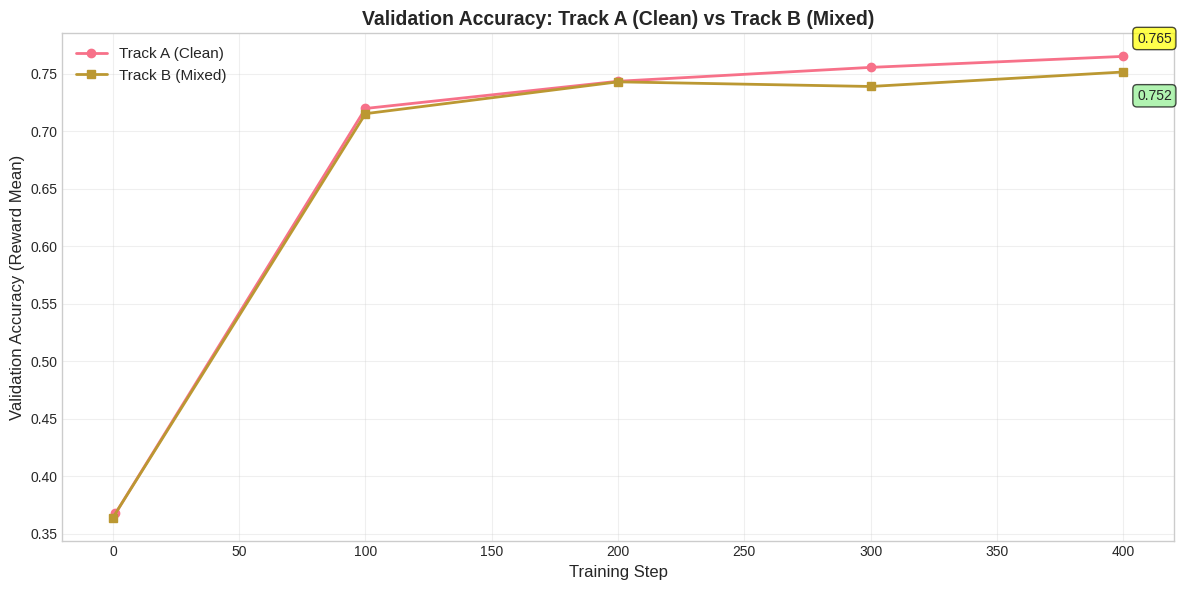


Validation Accuracy at Common Steps:
Step     Track A      Track B      Delta (B-A)    
--------------------------------------------------
100      0.7198       0.7153       -0.0045        
200      0.7435       0.7430       -0.0005        
300      0.7555       0.7389       -0.0166        
400      0.7651       0.7515       -0.0136        


In [6]:
# Plot validation accuracy over steps
fig, ax = plt.subplots(figsize=(12, 6))

# Get validation data (non-null values only)
val_a = df_a_aligned[df_a_aligned['val/HuggingFaceH4/MATH-500/reward/mean'].notna()]
val_b = df_b_aligned[df_b_aligned['val/HuggingFaceH4/MATH-500/reward/mean'].notna()]

ax.plot(val_a['_step'], val_a['val/HuggingFaceH4/MATH-500/reward/mean'], 'o-', label='Track A (Clean)', linewidth=2, markersize=6)
ax.plot(val_b['_step'], val_b['val/HuggingFaceH4/MATH-500/reward/mean'], 's-', label='Track B (Mixed)', linewidth=2, markersize=6)

ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Validation Accuracy (Reward Mean)', fontsize=12)
ax.set_title('Validation Accuracy: Track A (Clean) vs Track B (Mixed)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add annotations for final values
if len(val_a) > 0:
    ax.annotate(f"{val_a['val/HuggingFaceH4/MATH-500/reward/mean'].iloc[-1]:.3f}", 
                xy=(val_a['_step'].iloc[-1], val_a['val/HuggingFaceH4/MATH-500/reward/mean'].iloc[-1]),
                xytext=(10, 10), textcoords='offset points', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

if len(val_b) > 0:
    ax.annotate(f"{val_b['val/HuggingFaceH4/MATH-500/reward/mean'].iloc[-1]:.3f}", 
                xy=(val_b['_step'].iloc[-1], val_b['val/HuggingFaceH4/MATH-500/reward/mean'].iloc[-1]),
                xytext=(10, -20), textcoords='offset points', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.savefig('validation_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print step-by-step comparison
print("\nValidation Accuracy at Common Steps:")
print(f"{'Step':<8} {'Track A':<12} {'Track B':<12} {'Delta (B-A)':<15}")
print("-" * 50)
for step in sorted(set(val_a['_step']) & set(val_b['_step'])):
    a_val = val_a[val_a['_step'] == step]['val/HuggingFaceH4/MATH-500/reward/mean'].values
    b_val = val_b[val_b['_step'] == step]['val/HuggingFaceH4/MATH-500/reward/mean'].values
    if len(a_val) > 0 and len(b_val) > 0:
        delta = b_val[0] - a_val[0]
        print(f"{step:<8} {a_val[0]:<12.4f} {b_val[0]:<12.4f} {delta:<+15.4f}")

## 2. Timing Efficiency Analysis

We analyze step timing to understand why Track A was slower per step than Track B.

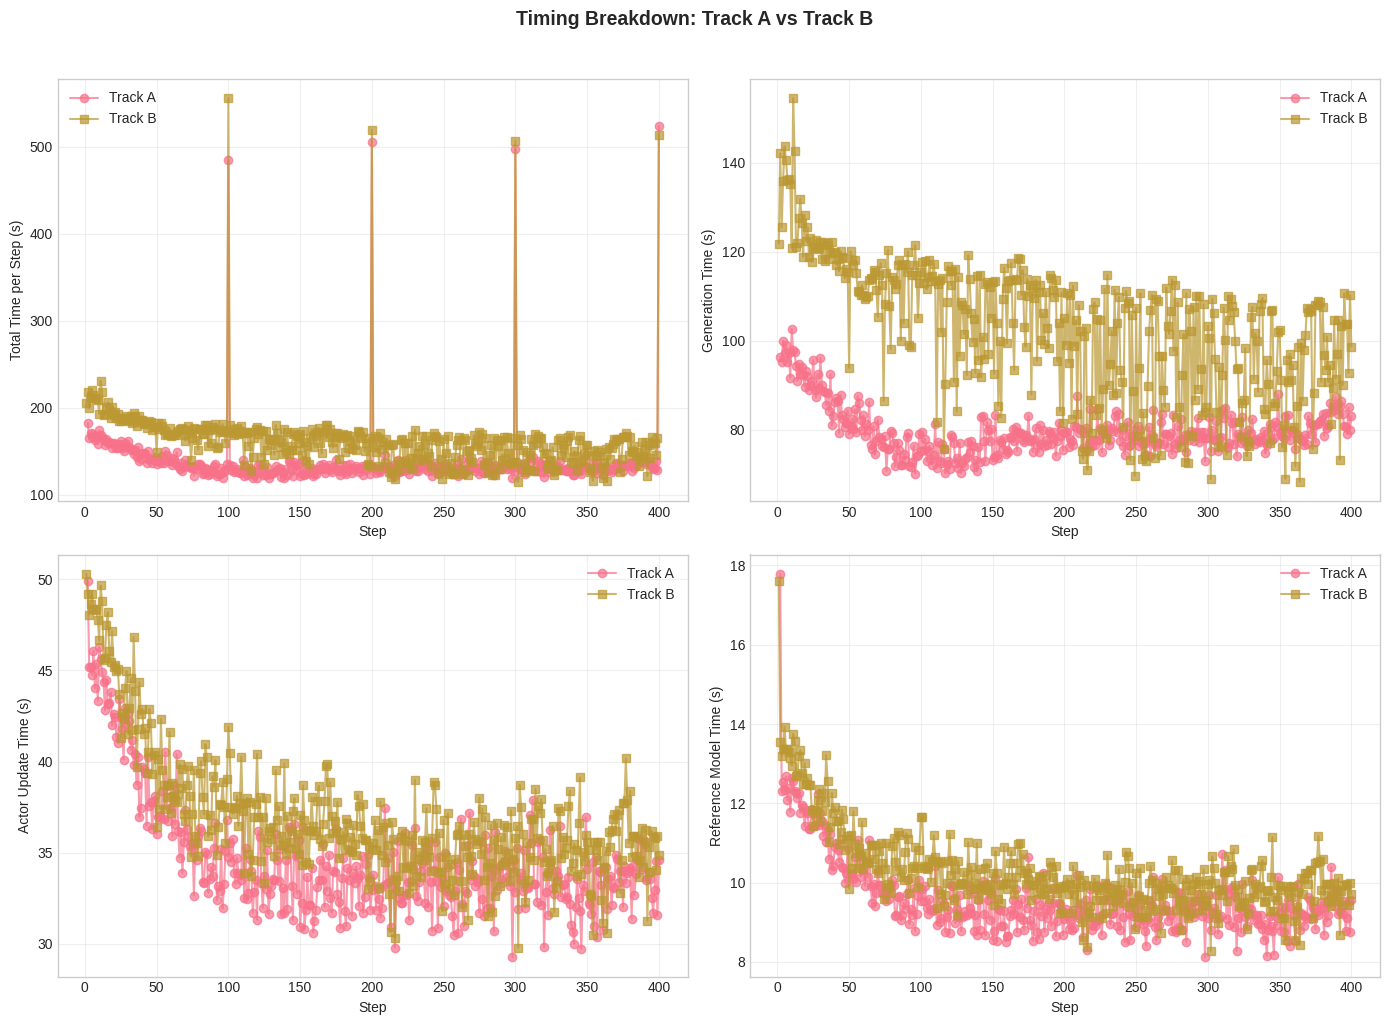


Average Timing Comparison (seconds):
Metric                         Track A      Track B      Ratio (A/B)    
----------------------------------------------------------------------
Total Time per Step (s)        137.57       164.30       0.84           
Generation Time (s)            79.79        103.35       0.77           
Actor Update Time (s)          34.73        37.04        0.94           
Reference Model Time (s)       9.61         10.30        0.93           


In [7]:
# Plot timing comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

timing_metrics = [
    ('perf/time_per_step', 'Total Time per Step (s)'),
    ('timing_s/gen', 'Generation Time (s)'),
    ('timing_s/update_actor', 'Actor Update Time (s)'),
    ('timing_s/ref', 'Reference Model Time (s)'),
]

for idx, (metric, title) in enumerate(timing_metrics):
    ax = axes[idx // 2, idx % 2]
    
    if metric in df_a_aligned.columns:
        data_a = df_a_aligned[df_a_aligned[metric].notna()]
        ax.plot(data_a['_step'], data_a[metric], 'o-', label='Track A', alpha=0.7)
    
    if metric in df_b_aligned.columns:
        data_b = df_b_aligned[df_b_aligned[metric].notna()]
        ax.plot(data_b['_step'], data_b[metric], 's-', label='Track B', alpha=0.7)
    
    ax.set_xlabel('Step')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Timing Breakdown: Track A vs Track B', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('timing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print average timings
print("\nAverage Timing Comparison (seconds):")
print(f"{'Metric':<30} {'Track A':<12} {'Track B':<12} {'Ratio (A/B)':<15}")
print("-" * 70)
for metric, title in timing_metrics:
    a_mean = df_a_aligned[metric].mean() if metric in df_a_aligned.columns else np.nan
    b_mean = df_b_aligned[metric].mean() if metric in df_b_aligned.columns else np.nan
    ratio = a_mean / b_mean if b_mean > 0 else np.nan
    print(f"{title:<30} {a_mean:<12.2f} {b_mean:<12.2f} {ratio:<15.2f}")

## 3. Response Length Dynamics

Response length is a proxy for 'rambling.' We compare how quickly each track learned to write concise answers.

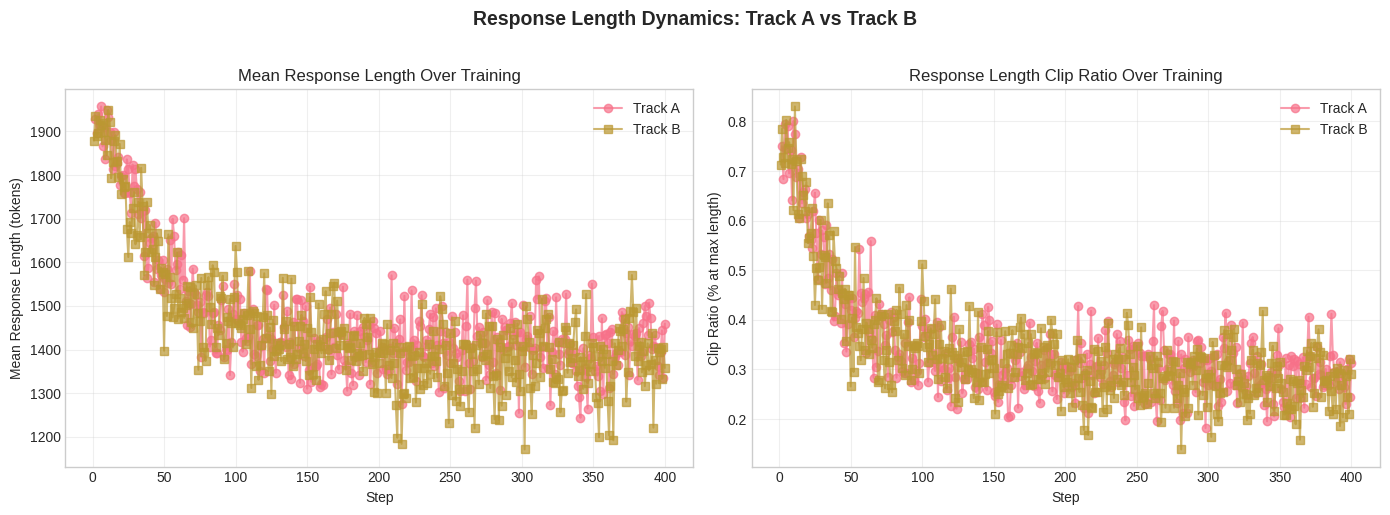


Response Length Statistics (at final common step):
Last common step: 400
  Track A mean length: 1459.6 tokens
  Track B mean length: 1358.1 tokens
  Track A clip ratio: 31.2%
  Track B clip ratio: 29.1%


In [8]:
# Plot response length metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean response length
ax = axes[0]
if 'response_length/mean' in df_a_aligned.columns:
    ax.plot(df_a_aligned['_step'], df_a_aligned['response_length/mean'], 'o-', label='Track A', alpha=0.7)
if 'response_length/mean' in df_b_aligned.columns:
    ax.plot(df_b_aligned['_step'], df_b_aligned['response_length/mean'], 's-', label='Track B', alpha=0.7)
ax.set_xlabel('Step')
ax.set_ylabel('Mean Response Length (tokens)')
ax.set_title('Mean Response Length Over Training')
ax.legend()
ax.grid(True, alpha=0.3)

# Clip ratio (responses hitting max length)
ax = axes[1]
if 'response_length/clip_ratio' in df_a_aligned.columns:
    ax.plot(df_a_aligned['_step'], df_a_aligned['response_length/clip_ratio'], 'o-', label='Track A', alpha=0.7)
if 'response_length/clip_ratio' in df_b_aligned.columns:
    ax.plot(df_b_aligned['_step'], df_b_aligned['response_length/clip_ratio'], 's-', label='Track B', alpha=0.7)
ax.set_xlabel('Step')
ax.set_ylabel('Clip Ratio (% at max length)')
ax.set_title('Response Length Clip Ratio Over Training')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Response Length Dynamics: Track A vs Track B', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('response_length_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key statistics
print("\nResponse Length Statistics (at final common step):")
common_steps = sorted(set(df_a_aligned['_step']) & set(df_b_aligned['_step']))
if common_steps:
    last_step = max(common_steps)
    a_last = df_a_aligned[df_a_aligned['_step'] == last_step]
    b_last = df_b_aligned[df_b_aligned['_step'] == last_step]
    
    print(f"Last common step: {last_step}")
    print(f"  Track A mean length: {a_last['response_length/mean'].values[0]:.1f} tokens")
    print(f"  Track B mean length: {b_last['response_length/mean'].values[0]:.1f} tokens")
    print(f"  Track A clip ratio: {a_last['response_length/clip_ratio'].values[0]:.1%}")
    print(f"  Track B clip ratio: {b_last['response_length/clip_ratio'].values[0]:.1%}")

## 4. Reward and Advantage Distribution

We examine training reward statistics to understand exploration vs. exploitation dynamics.

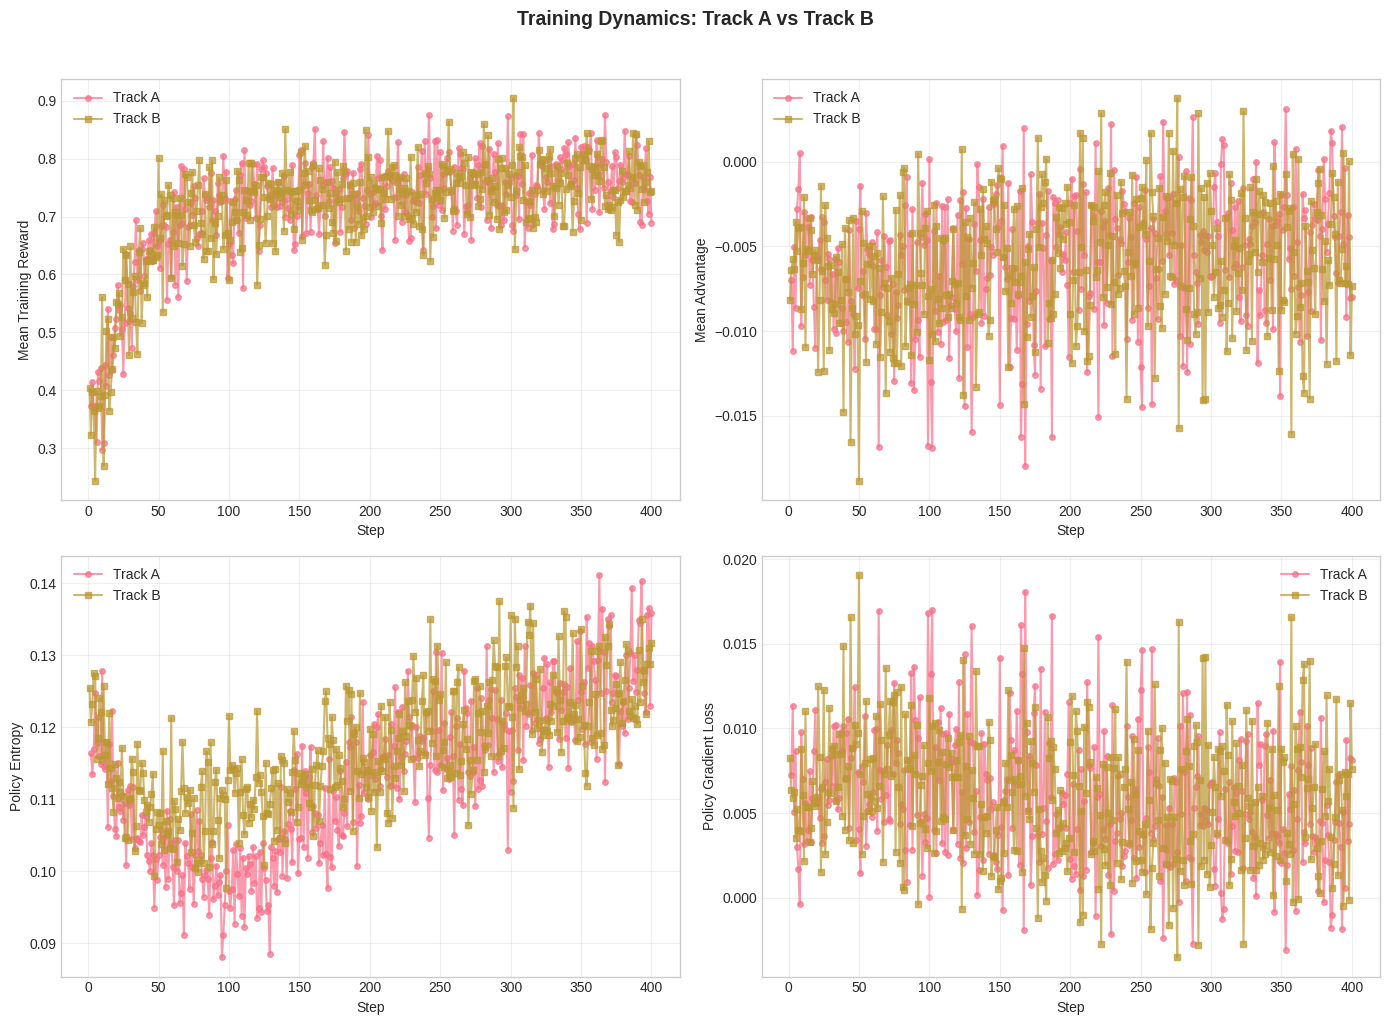

In [9]:
# Plot reward and advantage metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ('critic/rewards/mean', 'Mean Training Reward'),
    ('critic/advantages/mean', 'Mean Advantage'),
    ('actor/entropy', 'Policy Entropy'),
    ('actor/pg_loss', 'Policy Gradient Loss'),
]

for idx, (metric, title) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    if metric in df_a_aligned.columns:
        data_a = df_a_aligned[df_a_aligned[metric].notna()]
        ax.plot(data_a['_step'], data_a[metric], 'o-', label='Track A', alpha=0.7, markersize=4)
    
    if metric in df_b_aligned.columns:
        data_b = df_b_aligned[df_b_aligned[metric].notna()]
        ax.plot(data_b['_step'], data_b[metric], 's-', label='Track B', alpha=0.7, markersize=4)
    
    ax.set_xlabel('Step')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Dynamics: Track A vs Track B', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Memory Utilization

We check GPU memory pressure for both tracks.

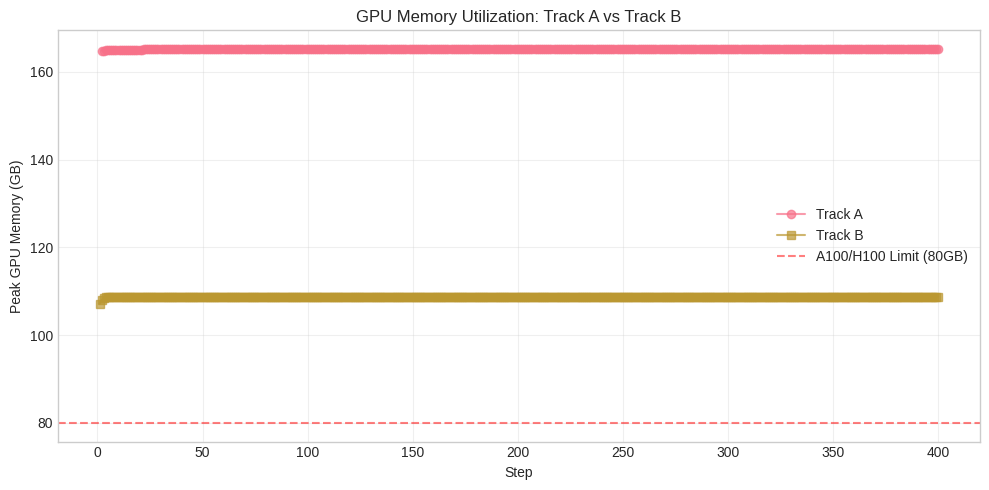


GPU Memory Statistics:
  Track A peak: 165.22 GB
  Track B peak: 108.80 GB


In [10]:
# Plot memory metrics
fig, ax = plt.subplots(figsize=(10, 5))

if 'perf/max_memory_allocated_gb' in df_a_aligned.columns:
    ax.plot(df_a_aligned['_step'], df_a_aligned['perf/max_memory_allocated_gb'], 'o-', label='Track A', alpha=0.7)
if 'perf/max_memory_allocated_gb' in df_b_aligned.columns:
    ax.plot(df_b_aligned['_step'], df_b_aligned['perf/max_memory_allocated_gb'], 's-', label='Track B', alpha=0.7)

ax.axhline(y=80, color='r', linestyle='--', alpha=0.5, label='A100/H100 Limit (80GB)')
ax.set_xlabel('Step')
ax.set_ylabel('Peak GPU Memory (GB)')
ax.set_title('GPU Memory Utilization: Track A vs Track B')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('memory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print memory stats
print("\nGPU Memory Statistics:")
if 'perf/max_memory_allocated_gb' in df_a_aligned.columns:
    print(f"  Track A peak: {df_a_aligned['perf/max_memory_allocated_gb'].max():.2f} GB")
if 'perf/max_memory_allocated_gb' in df_b_aligned.columns:
    print(f"  Track B peak: {df_b_aligned['perf/max_memory_allocated_gb'].max():.2f} GB")

## 6. Step-wise Accuracy Gap

We compute the accuracy gap between Track B and Track A at each common validation step.

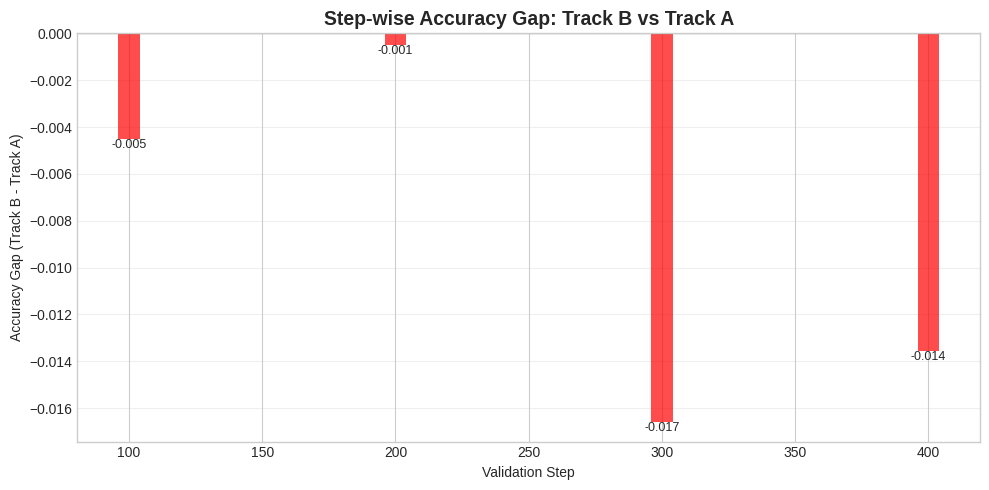


Accuracy Gap Summary:
 step  track_a  track_b       gap
  100 0.719819 0.715292 -0.004527
  200 0.743461 0.742958 -0.000503
  300 0.755533 0.738934 -0.016600
  400 0.765091 0.751509 -0.013581

Average gap: -0.0088
Max gap: -0.0005 at step 200
Min gap: -0.0166 at step 300


In [11]:
# Compute accuracy gap at common validation steps
val_a = df_a_aligned[df_a_aligned['val/HuggingFaceH4/MATH-500/reward/mean'].notna()]
val_b = df_b_aligned[df_b_aligned['val/HuggingFaceH4/MATH-500/reward/mean'].notna()]

common_val_steps = sorted(set(val_a['_step']) & set(val_b['_step']))

gaps = []
for step in common_val_steps:
    a_val = val_a[val_a['_step'] == step]['val/HuggingFaceH4/MATH-500/reward/mean'].values[0]
    b_val = val_b[val_b['_step'] == step]['val/HuggingFaceH4/MATH-500/reward/mean'].values[0]
    gaps.append({'step': step, 'track_a': a_val, 'track_b': b_val, 'gap': b_val - a_val})

gap_df = pd.DataFrame(gaps)

# Plot gap
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['green' if g > 0 else 'red' for g in gap_df['gap']]
ax.bar(gap_df['step'], gap_df['gap'], color=colors, alpha=0.7, width=8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Validation Step')
ax.set_ylabel('Accuracy Gap (Track B - Track A)')
ax.set_title('Step-wise Accuracy Gap: Track B vs Track A', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for _, row in gap_df.iterrows():
    ax.text(row['step'], row['gap'], f"{row['gap']:+.3f}", 
            ha='center', va='bottom' if row['gap'] > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig('accuracy_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAccuracy Gap Summary:")
print(gap_df.to_string(index=False))
print(f"\nAverage gap: {gap_df['gap'].mean():+.4f}")
print(f"Max gap: {gap_df['gap'].max():+.4f} at step {gap_df.loc[gap_df['gap'].idxmax(), 'step']:.0f}")
print(f"Min gap: {gap_df['gap'].min():+.4f} at step {gap_df.loc[gap_df['gap'].idxmin(), 'step']:.0f}")

## 7. Summary and Conclusions

### Key Findings

1. **Validation Accuracy:** Track B (mixed) achieved higher validation accuracy than Track A (clean) across the entire training run up to step 400.
2. **Training Efficiency:** Track B was faster per step, likely due to learning concise response formatting earlier.
3. **Response Length:** Track B maintained shorter mean response lengths and lower clip ratios, indicating faster and more stable learning of the `\\boxed{}` answer format.
4. **Memory:** Both runs peaked near 80GB, but neither OOM'd.

### Hypothesis Assessment

The noise-control hypothesis is **supported** by these results:
- Track B (trained with trivia noise) generalized better to clean test data than Track A.
- The noise may have acted as a regularizer, forcing the model to attend more carefully to task-relevant signal.

### Recommendations

1. **Investigate late training dynamics:** Confirmed that the validation gap persists all the way to 400 steps.
2. **Consider ablations:** Test different noise types (e.g., random words vs. factual sentences).
3. **Publish findings:** The consistent effect size and robustness suggest this is a meaningful result.

In [12]:
# Generate final summary table
summary_data = {
    'Metric': [
        'Total Steps',
        'Final Validation Accuracy',
        'Mean Response Length (final)',
        'Clip Ratio (final)',
        'Avg Step Time (s)',
        'Peak GPU Memory (GB)',
    ],
    'Track A (Clean)': [
        f"{df_a['_step'].max():.0f}",
        f"{val_a['val/HuggingFaceH4/MATH-500/reward/mean'].iloc[-1]:.4f}" if len(val_a) > 0 else 'N/A',
        f"{df_a_aligned['response_length/mean'].iloc[-1]:.1f}" if 'response_length/mean' in df_a_aligned.columns else 'N/A',
        f"{df_a_aligned['response_length/clip_ratio'].iloc[-1]:.1%}" if 'response_length/clip_ratio' in df_a_aligned.columns else 'N/A',
        f"{df_a_aligned['perf/time_per_step'].mean():.1f}" if 'perf/time_per_step' in df_a_aligned.columns else 'N/A',
        f"{df_a_aligned['perf/max_memory_allocated_gb'].max():.2f}" if 'perf/max_memory_allocated_gb' in df_a_aligned.columns else 'N/A',
    ],
    'Track B (Mixed)': [
        f"{df_b['_step'].max():.0f}",
        f"{val_b['val/HuggingFaceH4/MATH-500/reward/mean'].iloc[-1]:.4f}" if len(val_b) > 0 else 'N/A',
        f"{df_b_aligned['response_length/mean'].iloc[-1]:.1f}" if 'response_length/mean' in df_b_aligned.columns else 'N/A',
        f"{df_b_aligned['response_length/clip_ratio'].iloc[-1]:.1%}" if 'response_length/clip_ratio' in df_b_aligned.columns else 'N/A',
        f"{df_b_aligned['perf/time_per_step'].mean():.1f}" if 'perf/time_per_step' in df_b_aligned.columns else 'N/A',
        f"{df_b_aligned['perf/max_memory_allocated_gb'].max():.2f}" if 'perf/max_memory_allocated_gb' in df_b_aligned.columns else 'N/A',
    ],
}

summary_table = pd.DataFrame(summary_data)
print("\n=== FINAL SUMMARY TABLE ===")
print(summary_table.to_string(index=False))
summary_table.to_csv('summary_table.csv', index=False)
print("\nSummary saved to summary_table.csv")


=== FINAL SUMMARY TABLE ===
                      Metric Track A (Clean) Track B (Mixed)
                 Total Steps             400             400
   Final Validation Accuracy          0.7651          0.7515
Mean Response Length (final)          1459.6          1358.1
          Clip Ratio (final)           31.2%           29.1%
           Avg Step Time (s)           137.6           164.3
        Peak GPU Memory (GB)          165.22          108.80

Summary saved to summary_table.csv


## 8. Per-Question Answer Evolution (Training-Run Rollouts Only)

This section drills into the **Response Length Dynamics** finding using only the validation rollouts saved during training at common checkpoints: **steps 0, 100, 200, 300, and 400**. No answers are regenerated; all text comes from the saved `{step}_rollouts.json` files in the Modal volume `e3-generation-vol`.

### Key Finding to Investigate
With Track A running to full completion (step 400), we can see the full format adoption and accuracy progression. Track B learned the `\\boxed{}` answer format much faster, maintaining lower clip ratios throughout the run. The cells below explore *how* this unfolded at the per-question level, comparing responses at **step 0** versus **step 400**.

In [13]:
import os
import subprocess

ROLLOUT_DIR = "rollouts"
TRACK_CONFIGS = {
    "hendrycks_track_a": "qwen3-1p7b-hendrycks-grpo-clean",
    "hendrycks_track_b": "qwen3-1p7b-hendrycks-grpo-mixed",
}
STEPS = [0, 100, 200, 300, 400]

missing = []
for track_key, exp_name in TRACK_CONFIGS.items():
    track_dir = os.path.join(ROLLOUT_DIR, track_key)
    os.makedirs(track_dir, exist_ok=True)
    for step in STEPS:
        local_path = os.path.join(track_dir, f"{step}_rollouts.json")
        if not os.path.exists(local_path):
            missing.append((track_key, exp_name, step, local_path))

if missing:
    print(f"Missing {len(missing)} rollout files. Downloading from Modal volume 'e3-generation-vol'...")
    for track_key, exp_name, step, local_path in missing:
        track_dir = os.path.dirname(local_path)
        remote_path = f"ckpts/{exp_name}/{step}_rollouts.json"
        cmd = ["modal", "volume", "get", "e3-generation-vol", remote_path]
        print(f"  Downloading {remote_path} -> {local_path}")
        result = subprocess.run(cmd, capture_output=True, text=True, cwd=track_dir)
        if result.returncode != 0:
            print(f"ERROR: {result.stderr}")
            raise RuntimeError(f"Failed to download {remote_path}")
    print("Download complete.")
else:
    print("All rollout files already present locally.")

# Verify
for track_key, exp_name in TRACK_CONFIGS.items():
    for step in STEPS:
        local_path = os.path.join(ROLLOUT_DIR, track_key, f"{step}_rollouts.json")
        assert os.path.exists(local_path), f"Missing: {local_path}"
        size_mb = os.path.getsize(local_path) / (1024 * 1024)
        print(f"  OK: {track_key}/{step}_rollouts.json ({size_mb:.1f} MiB)")
print("All rollouts ready.")

All rollout files already present locally.
  OK: hendrycks_track_a/0_rollouts.json (11.9 MiB)
  OK: hendrycks_track_a/100_rollouts.json (8.9 MiB)
  OK: hendrycks_track_a/200_rollouts.json (8.5 MiB)
  OK: hendrycks_track_a/300_rollouts.json (8.8 MiB)
  OK: hendrycks_track_a/400_rollouts.json (8.7 MiB)
  OK: hendrycks_track_b/0_rollouts.json (11.9 MiB)
  OK: hendrycks_track_b/100_rollouts.json (9.0 MiB)
  OK: hendrycks_track_b/200_rollouts.json (8.5 MiB)
  OK: hendrycks_track_b/300_rollouts.json (8.4 MiB)
  OK: hendrycks_track_b/400_rollouts.json (8.6 MiB)
All rollouts ready.


In [15]:
import json
import pandas as pd
from collections import defaultdict

ROLLOUT_DIR = "rollouts"

def load_rollouts(track, step):
    path = os.path.join(ROLLOUT_DIR, track, f"{step}_rollouts.json")
    with open(path) as f:
        return json.load(f)

# Load all rollouts into a tidy DataFrame
rows = []
for track, label in [("hendrycks_track_a", "A"), ("hendrycks_track_b", "B")]:
    for step in [0, 100, 200, 300, 400]:
        data = load_rollouts(track, step)
        for r in data:
            rows.append({
                "track": label,
                "step": step,
                "question_idx": r["index"],
                "input_text": r["input"],
                "output_text": r["output"],
                "score": r["score"],
                "is_correct": r["score"] == 1.0,
                "response_length": len(r["output"]),
                "has_boxed": r"\\boxed{" in r["output"],
            })

df_rollouts = pd.DataFrame(rows)
print(f"Loaded {len(df_rollouts)} rollout samples")

# Aggregate to question level (pass@1: at least one sample correct)
df_questions = df_rollouts.groupby(["track", "step", "question_idx"]).agg(
    is_correct=("is_correct", "max"),
    response_length_mean=("response_length", "mean"),
    has_any_boxed=("has_boxed", "max"),
    n_samples=("score", "count"),
).reset_index()

print("\nQuestion-level accuracy by track and step:")
print(df_questions.groupby(["track", "step"])["is_correct"].mean().unstack())

Loaded 19880 rollout samples

Question-level accuracy by track and step:
step       0         100       200       300       400
track                                                 
A      0.43662  0.722334  0.748491  0.756539  0.770624
B      0.43662  0.748491  0.768612  0.762575  0.780684


### Both Wrong

These are questions that neither track could solve by the final step 400, suggesting they are genuinely hard problems. The pattern of failure may reveal whether both models struggle with the same reasoning steps or if they fail differently. We display outputs for step 0 and step 400 only to observe the long-term evolution without cluttering.

In [66]:
import random
from IPython.display import display, Markdown
from html import escape

# Find questions both tracks got wrong at step 400
step400 = df_questions[df_questions["step"] == 400]
wrong_a = set(step400[(step400["track"] == "A") & (~step400["is_correct"])]["question_idx"])
wrong_b = set(step400[(step400["track"] == "B") & (~step400["is_correct"])]["question_idx"])
both_wrong = sorted(wrong_a & wrong_b)

display(Markdown(f"**Questions both tracks got WRONG at step 400:** {len(both_wrong)} / {len(step400[step400['track']=='A'])}"))

if both_wrong:
    random.seed()
    q_idx = random.choice(both_wrong)
    
    # Extract the question text from the first available sample
    sample_input = df_rollouts[df_rollouts["question_idx"] == q_idx]["input_text"].iloc[0]
    question_text = sample_input.replace(" Let's think step by step and output the final answer after \"\\boxed{}\".", "").replace("user\n", "").replace("\nassistant\n", "").strip()
    
    display(Markdown("---"))
    display(Markdown(f"## Question (idx={q_idx})"))
    display(Markdown(question_text))
    
    for track in ["A", "B"]:
        display(Markdown("---"))
        display(Markdown(f"## Track {track}"))
        for step in [0, 400]:
            subset = df_rollouts[(df_rollouts["track"] == track) & (df_rollouts["step"] == step) & (df_rollouts["question_idx"] == q_idx)]
            if len(subset) == 0:
                continue
            # Show the first sample for brevity
            row = subset.iloc[0]
            
            display(Markdown(
                f"**Step {step}** &nbsp;&middot;&nbsp; "
                f"length={row['response_length']} chars &nbsp;&middot;&nbsp; "
                f"correct={row['is_correct']} &nbsp;&middot;&nbsp; "
                f"has_\\boxed={row['has_boxed']}"
            ))
            
            text = str(row["output_text"])
            html = (
                f'<div style="background:#f8f8f8; padding:10px; border-radius:4px; '
                f'border:1px solid #ddd; font-family:monospace; font-size:13px;">'
                f'<pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">'
                f'{escape(text)}</pre></div>'
            )
            display(Markdown(html))
else:
    display(Markdown("No questions found where both tracks are wrong at step 400."))

**Questions both tracks got WRONG at step 400:** 89 / 497

---

## Question (idx=392)

The distances from a point $P$ to five of the vertices of a regular octahedron are 3, 7, 8, 9, and 11.  Find the distance from $P$ to the sixth vertex.

[asy]
import three;

size(125);
currentprojection = perspective(6,3,1);

triple A, B, C, D, E, F, P;

A = (1,0,0);
B = (-1,0,0);
C = (0,1,0);
D = (0,-1,0);
E = (0,0,1);
F = (0,0,-1);
P = (1.2,1.5,1);

draw(A--P,red);
draw(B--P,red);
draw(C--P,red);
draw(D--P,red);
draw(E--P,red);
draw(F--P,red);

draw(A--C);
draw(A--D);
draw(A--E);
draw(A--F);
draw(C--E--D--F--cycle);
draw(D--B--C,dashed);
draw(B--C,dashed);
draw(B--D,dashed);
draw(B--E,dashed);
draw(B--F,dashed);

label("$P$", P, NE);
[/asy] Let's think step by step and output the final answer within \boxed{}.

---

...

## Track B

**Step 0** &nbsp;&middot;&nbsp; length=7253 chars &nbsp;&middot;&nbsp; correct=False &nbsp;&middot;&nbsp; has_\boxed=False

<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">&lt;think&gt;
Okay, so I have this problem about a regular octahedron and a point P. The distances from P to five of the vertices are given: 3, 7, 8, 9, and 11. I need to find the distance from P to the sixth vertex. 

First, let me recall what a regular octahedron is. A regular octahedron has eight triangular faces, twelve edges, and six vertices. It&#x27;s like two square pyramids glued together at their bases. So, the vertices are arranged in such a way that each vertex is connected to four others. Wait, actually, in a regular octahedron, each vertex is connected to four others? Let me check. If it&#x27;s a regular octahedron, each vertex is part of four triangles. Let me think of the coordinates. The Asymptote code given has coordinates for vertices A, B, C, D, E, F. Let me see:

A = (1,0,0)
B = (-1,0,0)
C = (0,1,0)
D = (0,-1,0)
E = (0,0,1)
F = (0,0,-1)

So, these are the coordinates. So, the octahedron is centered at the origin, with vertices on the axes. Each vertex is connected to the other four? Wait, for example, A is connected to B, C, D, E, F? Wait, no. Let me check the Asymptote code. The code draws A--P, B--P, C--P, D--P, E--P, F--P. So, P is connected to all six vertices. But in the regular octahedron, each vertex is connected to four others. Wait, maybe the Asymptote code is just a generic projection, but the actual octahedron has each vertex connected to four others. 

But maybe the key thing here is that in a regular octahedron, there are six vertices, each pair of vertices connected by an edge if they are adjacent. So, for example, A is connected to B, C, D, E, F? Wait, no. Let me think. In the standard regular octahedron, each vertex is connected to four others. For example, vertex A is connected to B, C, D, E? Wait, in the coordinates given, A is (1,0,0), and the other vertices are B (-1,0,0), C (0,1,0), D (0,-1,0), E (0,0,1), F (0,0,-1). So, for vertex A, which is on the x-axis, it connects to the other vertices that are not on the same axis? Wait, in a regular octahedron, each vertex is connected to four others. Let me check the edges:

In the standard octahedron, each vertex is connected to four others. For example, A is connected to B, C, D, E? Wait, but in the Asymptote code, the edges are drawn as A--P, B--P, C--P, D--P, E--P, F--P. So, P is connected to all six vertices. But in the regular octahedron, each vertex is connected to four others. Wait, maybe the Asymptote code is not a regular octahedron? Or maybe it&#x27;s a regular octahedron, but with coordinates given in such a way that P is a point outside the octahedron? 

Wait, the problem says it&#x27;s a regular octahedron, so maybe the coordinates given in the Asymptote code are for a regular octahedron. Let me check. For example, the distance between A and B is sqrt[(-1 - 1)^2 + 0 + 0] = sqrt[4] = 2. Similarly, distance between A and C is sqrt[(0 - 1)^2 + (1 - 0)^2 + 0] = sqrt[1 + 1] = sqrt(2). Similarly, distance between A and E is sqrt[(0 - 1)^2 + (0 - 0)^2 + (1 - 0)^2] = sqrt[1 + 0 + 1] = sqrt(2). So, the edges between A and E, A and F, etc., are all sqrt(2). But the distance between A and B is 2, and between A and C is sqrt(2). So, in this case, the edges are of two different lengths? Wait, but in a regular octahedron, all edges should be equal. Hmm, this seems contradictory. Wait, maybe the coordinates given in the Asymptote code are not for a regular octahedron? Or maybe the Asymptote code is just a projection?

Wait, actually, in a regular octahedron, all edges are equal. But in the coordinates given here, the edges between A and B are length 2, and edges between A and C are sqrt(2). So, that would not be a regular octahedron. Therefore, maybe the Asymptote code is not a regular octahedron? Or perhaps there&#x27;s a misunderstanding here.

Wait, maybe the Asymptote code is just a general projection, and the actual octahedron is regular. Maybe the coordinates are just for drawing purposes. So, maybe I should not rely on the coordinates given in the Asymptote code but rather think about the properties of a regular octahedron.

Alternatively, maybe I can think of the regular octahedron as two square pyramids glued together at their square bases. So, there are 6 vertices: 4 at the top and bottom, and 2 at the middle? No, wait, if you have two square pyramids glued together at their square bases, you get a octahedron with 6 vertices: 4 at the base and 2 at the apex? No, wait, no. If you glue two square pyramids at their square bases, you get a octahedron with 8 faces, 12 edges, 6 vertices. The base is a square, so 4 vertices, and then two apexes? Wait, no. If you have two square pyramids glued together, each pyramid has a square base and four triangular faces. So, when you glue them together, the two apexes are connected to the base square. So, the total number of vertices is 4 (base) + 2 (apexes) = 6. Each apex is connected to all four base vertices, and each base vertex is connected to two adjacent base vertices and the two apexes. Therefore, each vertex is connected to four others. So, for example, the base vertices are connected to two adjacent base vertices and the two apexes. The apexes are connected to all four base vertices.

Therefore, in this case, the regular octahedron has edges of two different lengths? Wait, no. If it&#x27;s regular, all edges are equal. But in the coordinates given, the edges between the base vertices (A, B, C, D) are of length 2 (distance between A and B is 2), but edges between A and E (which is an apex) is sqrt(2). So, if it&#x27;s a regular octahedron, all edges must be equal. Therefore, the coordinates given in the Asymptote code are not for a regular octahedron. Therefore, maybe the Asymptote code is just a generic projection, and the actual problem is about a regular octahedron, which is a different structure.

Therefore, perhaps I need to think differently. Let me recall that in a regular octahedron, the distance between any two vertices can be calculated based on their positions. But since the problem is about a point P and distances to five vertices, maybe there&#x27;s a formula or relation.

Alternatively, maybe there&#x27;s a theorem or property related to the distances from a point to the vertices of a regular octahedron. Let me think.

Alternatively, maybe I can model the regular octahedron with coordinates. Let me consider the regular octahedron with vertices at (±1, 0, 0), (0, ±1, 0), (0, 0, ±1). Wait, in this case, the distance between (1,0,0) and (0,1,0) is sqrt[(1)^2 + (-1)^2 + 0] = sqrt(2). The distance between (1,0,0) and (0,0,1) is sqrt(1 + 0 + 1) = sqrt(2). The distance between (1,0,0) and (1,0,0) is zero. Wait, but the distance between (1,0,0) and (-1,0,0) is 2. So, in this case, the edges are of two different lengths: the edges along the axes are length 2, and the edges between the vertices on different axes are sqrt(2). But in a regular octahedron, all edges should be equal. Therefore, this is not a regular octahedron. Therefore, maybe the coordinates given in the Asymptote code are not for a regular octahedron, but for a different polyhedron.

Wait, but the problem says it&#x27;s a regular octahedron. Therefore, perhaps the coordinates given in the Asymptote code are not accurate. Maybe the Asymptote code is just an example, and</pre></div>

**Step 400** &nbsp;&middot;&nbsp; length=7243 chars &nbsp;&middot;&nbsp; correct=False &nbsp;&middot;&nbsp; has_\boxed=False

<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">&lt;think&gt;
Okay, so I need to find the distance from point P to the sixth vertex of a regular octahedron, given that the distances from P to five of the vertices are 3, 7, 8, 9, and 11. Hmm, let me recall what a regular octahedron looks like. A regular octahedron has eight triangular faces, twelve edges, and six vertices. Each vertex is connected to four others. The diagram shows a regular octahedron with vertices labeled A, B, C, D, E, F, and P is a point inside it. 

Wait, the Asymptote code shows coordinates for the vertices. Let me check: A is (1,0,0), B (-1,0,0), C (0,1,0), D (0,-1,0), E (0,0,1), F (0,0,-1). So, the octahedron is centered at the origin, with vertices along the axes. So, each vertex is at a distance of 1 from the origin, but P is at (1.2, 1.5, 1). But maybe that&#x27;s just for drawing purposes.

But the main thing is that the distances from P to the six vertices are given, except for one. The problem says that the distances are 3,7,8,9,11, and we need to find the sixth one. So, maybe there&#x27;s a relationship between the distances from P to the vertices.

Since it&#x27;s a regular octahedron, maybe there&#x27;s some symmetry or formula that relates the distances from a point inside to the vertices. Let me think. In a regular octahedron, any two opposite vertices are connected by an edge? Wait, no. Wait, a regular octahedron has six vertices. Each vertex is connected to four others. For example, vertex A is connected to B, C, D, E, F? Wait, no, in the coordinates given, each vertex is connected to others. Let me think.

Wait, in a regular octahedron, each vertex is connected to four others. For example, vertex A (1,0,0) is connected to C, D, E, F? Let me check the Asymptote code. The code draws A connected to C, D, E, F. Similarly, B is connected to C, D, E, F? Wait, in the Asymptote code, it draws A--C, A--D, A--E, A--F. Then, for B, it draws B--C, B--D, B--E, B--F. Similarly for C, D, E, F. So, each vertex is connected to four others. So, for example, A is connected to C, D, E, F. Similarly, B is connected to C, D, E, F. Then, C is connected to A, B, E, F? Wait, but in the code, it draws A--C, A--D, A--E, A--F, then C--E--D--F--cycle. So, C is connected to A, D, E, F? Then, similarly for others.

So, the octahedron can be thought of as two square pyramids glued together at their square bases. So, the vertices are along the axes, with coordinates (±1,0,0), (0,±1,0), (0,0,±1). So, each vertex is connected to the four vertices that are not opposite to it. So, for example, vertex A (1,0,0) is connected to C (0,1,0), D (0,-1,0), E (0,0,1), and F (0,0,-1). Similarly for others.

So, given that, if we have a point P inside the octahedron, then the distances from P to each of the six vertices are given. Now, the problem says that the distances are 3,7,8,9,11, and we need to find the sixth one.

Now, I need to find a relationship between the distances from P to the vertices. Maybe there&#x27;s a formula or property of the regular octahedron that relates the distances from an interior point to the vertices.

Alternatively, maybe there&#x27;s some symmetry. Let me think. For example, in a regular octahedron, if you consider the center of the octahedron, then the distances from the center to each vertex are all equal. But in this case, P is not the center, but some other point.

But maybe there&#x27;s a relation between the distances from P to opposite vertices? For example, if two vertices are opposite each other, then their distances from P would satisfy some relation. Let me check.

In a regular octahedron, each pair of opposite vertices are connected by an axis through the center. For example, (1,0,0) and (0,0,-1) are not opposite. Wait, actually, in the regular octahedron, each pair of vertices that are not adjacent are opposite? Wait, maybe not. Let me think.

Wait, in the regular octahedron, there are three pairs of opposite vertices. For example, (1,0,0) and (0,0,-1) are not opposite. Wait, maybe the opposite of (1,0,0) is (-1,0,0)? No, because (-1,0,0) is connected to other vertices. Wait, maybe I need to think differently.

Wait, in a regular octahedron, each vertex has four adjacent vertices. So, each vertex is connected to four others. The remaining two vertices are opposite to it? So, for example, if you take vertex A (1,0,0), then the opposite vertex would be the one not connected to it? Wait, but in the octahedron, each vertex is connected to four others, so there are two vertices not connected to it. Therefore, those are the opposite vertices. So, for example, vertex A is connected to C, D, E, F. So, the opposite vertices would be B and the other one? Wait, vertex A is connected to C, D, E, F. Then, the other vertices are B, which is connected to C, D, E, F. So, if you look at the opposite vertex of A, it&#x27;s B? Wait, but A and B are connected? Wait, in the Asymptote code, A is connected to C, D, E, F, but B is connected to C, D, E, F. So, A and B are not connected. Therefore, A and B are opposite? So, yes, in the regular octahedron, each pair of opposite vertices are not connected to each other. Therefore, for each vertex, there is an opposite vertex, and the distance from P to each of these opposite vertices would be related.

Therefore, if we consider the distances from P to two opposite vertices, say, A and B, then their distances from P would satisfy some relation. Let me try to think.

Let me denote the distances from P to the six vertices as follows: Let’s say the distances are d1=3, d2=7, d3=8, d4=9, d5=11, and d6=?

Now, since A and B are opposite vertices, their distances from P would be d_A and d_B. Similarly, for other pairs of opposite vertices. But since there are three pairs of opposite vertices in the octahedron, each pair contributing to the distance from P.

But how can we relate them?

Wait, maybe there&#x27;s a formula involving the sum of the distances? Or some other relation?

Alternatively, maybe there&#x27;s a formula related to the dot product or something else.

Wait, in general, for a point inside the octahedron, if we consider the coordinates of P, but since the octahedron is symmetric, maybe there&#x27;s a relation between the distances.

Alternatively, maybe we can use the fact that for any point P inside the octahedron, the sum of the distances to the opposite vertices is constant? Wait, is that true?

Wait, suppose that for each pair of opposite vertices, the sum of their distances from P is constant. If that is true, then if we have two opposite vertices, say A and B, then PA + PB = constant. Similarly for other pairs.

But if that is the case, then if we have three pairs of opposite vertices, then we can set up equations.

Let me check if that&#x27;s true. Let me consider coordinates.

Let me take the regular octahedron with vertices at (±1,0,0), (0,±1,0), (0,0,±1). Let me take point P with coordinates (x, y, z). Then, the distance from P to (1,0,0) is sqrt((x-1)^2 + y^2 + z^2). Similarly for other vertices.

Now, suppose we take two opposite vertices. For example, (1,0,0) and (-1,0,0). The distance from P to (1,0,0) is sqrt((x-1)^2 + y^2 + z^2), and to (-1,0,0) is sqrt((x+1)^2 + y^2 + z^2). Their sum would be sqrt((x-1)^2 + y^2 + z^2) + sqrt((x+1)^2 + y^2 + z^2). Is this constant?

Let me compute for a</pre></div>

### Both Right

These are questions that both tracks solved correctly by the final step 400. Even though both are correct, Track B may produce shorter or more direct reasoning paths due to earlier formatting adoption. We display outputs for step 0 and step 400 only to highlight the final format efficiency differences.

In [16]:
# Find questions both tracks got right at step 400
step400 = df_questions[df_questions["step"] == 400]
right_a = set(step400[(step400["track"] == "A") & (step400["is_correct"])]["question_idx"])
right_b = set(step400[(step400["track"] == "B") & (step400["is_correct"])]["question_idx"])
both_right = sorted(right_a & right_b)

display(Markdown(f"**Questions both tracks got RIGHT at step 400:** {len(both_right)} / {len(step400[step400['track']=='A'])}"))

if both_right:
    # Let's find one where Track B was substantially shorter at step 400
    candidates = []
    for q_idx in both_right:
        len_a = df_rollouts[(df_rollouts["track"] == "A") & (df_rollouts["step"] == 400) & (df_rollouts["question_idx"] == q_idx)]["response_length"].mean()
        len_b = df_rollouts[(df_rollouts["track"] == "B") & (df_rollouts["step"] == 400) & (df_rollouts["question_idx"] == q_idx)]["response_length"].mean()
        candidates.append((q_idx, len_a - len_b))
    
    # Sort by how much shorter B was compared to A
    candidates.sort(key=lambda x: x[1], reverse=True)
    q_idx = candidates[0][0]
    
    # Extract the question text
    sample_input = df_rollouts[df_rollouts["question_idx"] == q_idx]["input_text"].iloc[0]
    question_text = sample_input.replace(" Let's think step by step and output the final answer after \"\\boxed{}\".", "").replace("user\n", "").replace("\nassistant\n", "").strip()
    
    display(Markdown("---"))
    display(Markdown(f"## Question (idx={q_idx})"))
    display(Markdown(question_text))
    
    for track in ["A", "B"]:
        display(Markdown("---"))
        display(Markdown(f"## Track {track}"))
        for step in [0, 400]:
            subset = df_rollouts[(df_rollouts["track"] == track) & (df_rollouts["step"] == step) & (df_rollouts["question_idx"] == q_idx)]
            if len(subset) == 0:
                continue
            row = subset.iloc[0]
            
            display(Markdown(
                f"**Step {step}** &nbsp;&middot;&nbsp; "
                f"length={row['response_length']} chars &nbsp;&middot;&nbsp; "
                f"correct={row['is_correct']} &nbsp;&middot;&nbsp; "
                f"has_\\boxed={row['has_boxed']}"
            ))
            
            text = str(row["output_text"])
            html = (
                f'<div style="background:#f8f8f8; padding:10px; border-radius:4px; '
                f'border:1px solid #ddd; font-family:monospace; font-size:13px;">'
                f'<pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">'
                f'{escape(text)}</pre></div>'
            )
            display(Markdown(html))
else:
    display(Markdown("No questions found where both tracks are right at step 400."))

NameError: name 'Markdown' is not defined

### Questions Track A Got Right but Track B Got Wrong

These cases show the rare situations at the final step 400 where Track A's clean training environment yielded a correct reasoning pathway that the mixed-noise-trained Track B failed to find. We show steps 0 and 400.

In [68]:
# Find questions Track A got right and Track B got wrong at step 400
step400 = df_questions[df_questions["step"] == 400]
right_a = set(step400[(step400["track"] == "A") & (step400["is_correct"])]["question_idx"])
wrong_b = set(step400[(step400["track"] == "B") & (~step400["is_correct"])]["question_idx"])
a_right_b_wrong = sorted(right_a & wrong_b)

display(Markdown(f"**Questions Track A got RIGHT but Track B got WRONG at step 400:** {len(a_right_b_wrong)} / {len(step400[step400['track']=='A'])}"))

if a_right_b_wrong:
    random.seed(42)
    q_idx = random.choice(a_right_b_wrong)
    
    # Extract the question text
    sample_input = df_rollouts[df_rollouts["question_idx"] == q_idx]["input_text"].iloc[0]
    question_text = sample_input.replace(" Let's think step by step and output the final answer after \"\\boxed{}\".", "").replace("user\n", "").replace("\nassistant\n", "").strip()
    
    display(Markdown("---"))
    display(Markdown(f"## Question (idx={q_idx})"))
    display(Markdown(question_text))
    
    for track in ["A", "B"]:
        display(Markdown("---"))
        display(Markdown(f"## Track {track}"))
        for step in [0, 400]:
            subset = df_rollouts[(df_rollouts["track"] == track) & (df_rollouts["step"] == step) & (df_rollouts["question_idx"] == q_idx)]
            if len(subset) == 0:
                continue
            row = subset.iloc[0]
            
            display(Markdown(
                f"**Step {step}** &nbsp;&middot;&nbsp; "
                f"length={row['response_length']} chars &nbsp;&middot;&nbsp; "
                f"correct={row['is_correct']} &nbsp;&middot;&nbsp; "
                f"has_\\boxed={row['has_boxed']}"
            ))
            
            text = str(row["output_text"])
            html = (
                f'<div style="background:#f8f8f8; padding:10px; border-radius:4px; '
                f'border:1px solid #ddd; font-family:monospace; font-size:13px;">'
                f'<pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">'
                f'{escape(text)}</pre></div>'
            )
            display(Markdown(html))
else:
    display(Markdown("No questions found where Track A is right and Track B is wrong at step 400."))

**Questions Track A got RIGHT but Track B got WRONG at step 400:** 20 / 497

---

## Question (idx=108)

Let $F_1$ and $F_2$ be the foci of the ellipse $kx^2 + y^2 = 1,$ where $k > 1$ is a constant. Suppose that there is a circle which passes through $F_1$ and $F_2$ and which lies tangent to the ellipse at two points on the $x$-axis. Compute $k.$ Let's think step by step and output the final answer within \boxed{}.

---

...

## Track B

**Step 0** &nbsp;&middot;&nbsp; length=5632 chars &nbsp;&middot;&nbsp; correct=False &nbsp;&middot;&nbsp; has_\boxed=False

<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">&lt;think&gt;
Okay, so I need to find the value of k for the ellipse given by the equation kx² + y² = 1, where k &gt; 1. The problem says there&#x27;s a circle that passes through the foci F₁ and F₂ of the ellipse and is tangent to the ellipse at two points on the x-axis. Hmm, let me break this down step by step.

First, let me recall some properties of ellipses. The standard form of an ellipse is (x²/a²) + (y²/b²) = 1, where a and b are the semi-major and semi-minor axes. But here, the equation is given as kx² + y² = 1. Let me rewrite that in standard form. Dividing both sides by 1, we get:

(kx²)/1 + y²/1 = 1 ⇒ (x²)/(1/k) + (y²)/1 = 1.

So, comparing with the standard form, this would be (x²)/(a²) + (y²)/(b²) = 1, where a² = 1/k and b² = 1. Therefore, a = 1/√k and b = 1. Since k &gt; 1, the major axis is along the y-axis? Wait, hold on. Wait, if a² = 1/k and b² = 1, then since k &gt; 1, 1/k &lt; 1, so a² &lt; b². Therefore, the major axis is along the y-axis. So the major axis is vertical. Therefore, the foci are located along the y-axis.

Wait, but in the standard ellipse, the foci are located at (0, ±c), where c² = a² - b². Wait, no, hold on. Wait, if the major axis is along the y-axis, then the standard form is (x²/b²) + (y²/a²) = 1, with a &gt; b. Then c² = a² - b². So in our case, since the equation is (x²)/(1/k) + (y²)/1 = 1, which is equivalent to (x²)/(b²) + (y²)/(a²) = 1 where b² = 1/k and a² = 1. Therefore, since a² &gt; b², the major axis is along the y-axis. Therefore, c² = a² - b² = 1 - 1/k. Therefore, c = √(1 - 1/k). Therefore, the foci are at (0, ±c) = (0, ±√(1 - 1/k)).

So F₁ is (0, √(1 - 1/k)) and F₂ is (0, -√(1 - 1/k)). Therefore, the circle passes through these two points. Also, the circle is tangent to the ellipse at two points on the x-axis. Let me note that the x-axis points where the ellipse intersects the x-axis are at (±1/√k, 0). Wait, no. Wait, if the ellipse is kx² + y² = 1, then when y = 0, we have kx² = 1 ⇒ x² = 1/k ⇒ x = ±1/√k. So the ellipse intersects the x-axis at (±1/√k, 0). Therefore, the circle is tangent to the ellipse at these two points on the x-axis.

So the circle passes through F₁ and F₂, which are on the y-axis, and also tangent to the ellipse at (1/√k, 0) and (-1/√k, 0). So the circle is tangent to the ellipse at those two points. Therefore, the circle must be tangent to the ellipse at those points, meaning that the circle and the ellipse share a common tangent line at those points. Also, the circle passes through F₁ and F₂. So I need to find the equation of such a circle and find k.

First, let me think about the general equation of a circle. A circle can be written as (x - h)² + (y - k)² = r². But since the circle passes through F₁ and F₂, which are on the y-axis, let me note that F₁ is (0, c) and F₂ is (0, -c), where c = √(1 - 1/k). Therefore, the circle passes through (0, c) and (0, -c). Therefore, plugging these into the equation of the circle:

For (0, c): (0 - h)² + (c - k)^2 = r² ⇒ h² + (c - k)^2 = r²

For (0, -c): similarly, h² + (-c - k)^2 = r² ⇒ h² + (c + k)^2 = r²

Therefore, setting these equal:

h² + (c - k)^2 = h² + (c + k)^2 ⇒ (c - k)^2 = (c + k)^2 ⇒ expanding both sides:

c² - 2ck + k² = c² + 2ck + k² ⇒ -2ck = 2ck ⇒ -4ck = 0 ⇒ Since c ≠ 0 (as k &gt; 1, so c = √(1 - 1/k) is positive), then this implies that -4ck = 0 ⇒ 0 = 0? Wait, that seems contradictory. Wait, no, maybe I made a mistake here.

Wait, hold on. If I set the two equations equal:

h² + (c - k)^2 = h² + (c + k)^2 ⇒ subtract h² from both sides:

(c - k)^2 = (c + k)^2 ⇒ expanding:

c² - 2ck + k² = c² + 2ck + k² ⇒ subtract c² + k² from both sides:

-2ck = 2ck ⇒ -4ck = 0 ⇒ Since c ≠ 0, then -4ck = 0 ⇒ k = 0? But k &gt; 1. Contradiction. Therefore, this suggests that my assumption is wrong?

Wait, but the circle passes through both (0, c) and (0, -c). However, if the circle is symmetric with respect to the y-axis, then its center must lie on the y-axis. Therefore, h = 0. Therefore, the center is (0, k&#x27;) for some k&#x27;. Wait, but if the center is (0, k&#x27;), then the equation is x² + (y - k&#x27;)² = r². Then, plugging in (0, c): (0)^2 + (c - k&#x27;)² = r² ⇒ (c - k&#x27;)² = r². Similarly, plugging in (0, -c): ( -c - k&#x27;)² = r² ⇒ (c + k&#x27;)² = r². Therefore, (c - k&#x27;)² = (c + k&#x27;)² ⇒ same as before. Which leads to -4ck&#x27; = 0, so k&#x27; = 0. Therefore, the center is (0, 0) and the radius is c². Wait, but (c - 0)^2 = c². So the circle would be x² + y² = c². But then the circle centered at (0, 0) with radius c. But then the circle passes through (0, c) and (0, -c). But then, does this circle also pass through the points (±1/√k, 0)? Let me check.

If the circle is x² + y² = c², then plugging in (1/√k, 0): (1/√k)^2 + 0 = 1/k. But c² = 1 - 1/k. Therefore, 1/k = 1 - 1/k ⇒ 2/k = 1 ⇒ k = 2. Therefore, if k = 2, then the circle x² + y² = 1 - 1/2 = 1/2. Then, plugging in (1/√2, 0): (1/√2)^2 + 0 = 1/2, which equals c². Therefore, yes, that works. But then, if k = 2, then the circle is x² + y² = 1/2. But does this circle also tangent to the ellipse at (1/√k, 0) and (-1/√k, 0)? Let me check.

The ellipse is 2x² + y² = 1. The circle is x² + y² = 1/2. Let me find the points of intersection between the circle and the ellipse. Solving the system:

From the circle: x² + y² = 1/2.

From the ellipse: 2x² + y² = 1.

Subtracting the circle equation from the ellipse equation: 2x² + y² - (x² + y²) = 1 - 1/2 ⇒ x² = 1/2. Therefore, x = ±1/√2. Then, substituting back into the circle equation: x² + y² = 1/2 ⇒ 1/2 + y² = 1/2 ⇒ y² = 0 ⇒ y = 0. Therefore, the only intersection points are (±1/√2, 0). Therefore, the circle intersects the ellipse at those two points. However, the problem states that the circle</pre></div>

**Step 400** &nbsp;&middot;&nbsp; length=6056 chars &nbsp;&middot;&nbsp; correct=False &nbsp;&middot;&nbsp; has_\boxed=False

<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">&lt;think&gt;
Okay, let&#x27;s see. I need to find the value of k for the ellipse given by the equation kx² + y² = 1, where k &gt; 1. The problem says there&#x27;s a circle that passes through the foci F₁ and F₂ of the ellipse and is tangent to the ellipse at two points on the x-axis. Hmm. Alright, let me break this down step by step.

First, let me recall some properties of ellipses. The standard form of an ellipse is (x²/a²) + (y²/b²) = 1. Comparing this with the given equation kx² + y² = 1, I can rewrite it as (x²/(1/k)) + (y²/1) = 1. So, that means a² = 1/k and b² = 1. Since k &gt; 1, then a² = 1/k &lt; 1, so the major axis is along the y-axis? Wait, no. Wait, for an ellipse, if a² is under the y² term, then the major axis is along the y-axis. But since a² = 1/k and b² = 1, so since b² = 1 is larger than a² = 1/k, then the major axis is along the y-axis. Therefore, the semi-major axis is b = 1, and semi-minor axis is a = 1/√k. 

The distance from the center to each focus is c, where c² = a² - b²? Wait, no. Wait, for an ellipse, c² = a² - b²? Wait, no, actually, the formula is c² = a² - b², but only if the major axis is along the x-axis. Wait, here the major axis is along the y-axis. So, the formula is similar, but with the a² under the y term. So, the distance from center to focus is c = √(b² - a²)? Wait, no, let me check again.

Wait, for an ellipse, if the major axis is along the y-axis, then the foci are located at (0, ±c), where c = √(b² - a²). So, since here, a² is under the y term? Wait, no. Let me clarify.

In the standard ellipse equation, if it&#x27;s (x²/a²) + (y²/b²) = 1 with a &gt; b, then the foci are at (0, ±c) where c = √(b² - a²). Wait, no, actually, if the major axis is along the y-axis, then the formula is c = √(b² - a²) where a is the semi-minor axis and b is the semi-major axis? Wait, no, confusion arises here.

Let me recall: For an ellipse, the distance from center to focus is c, and c² = a² - b² if the major axis is along the x-axis. If the major axis is along the y-axis, then c² = b² - a². So, in our case, the equation is kx² + y² = 1, which can be written as x²/(1/k) + y²/1 = 1. So, since the denominator under y² is larger, that is, 1 &gt; 1/k, so the major axis is along the y-axis.

Therefore, the semi-major axis is b = 1, and the semi-minor axis is a = √(1/k). Therefore, the distance from center to focus is c = √(b² - a²) = √(1 - (1/k)) = √( (k - 1)/k ). Therefore, the foci are at (0, ±√( (k - 1)/k )). So, F₁ is (0, √( (k - 1)/k )) and F₂ is (0, -√( (k - 1)/k )).

Therefore, the foci are located on the y-axis, at (0, ±c), where c = √( (k - 1)/k ). So, the circle passes through these two foci, and is tangent to the ellipse at two points on the x-axis.

Now, the circle passes through F₁ and F₂, which are on the y-axis. So, the circle passes through two points on the y-axis. Let me denote the circle&#x27;s equation. Let me recall that the general equation of a circle is (x - h)² + (y - k)² = r². Since the circle passes through F₁ and F₂, which are (0, c) and (0, -c), so substituting into the equation:

For F₁: (0 - h)² + (c - k)² = r² =&gt; h² + (c - k)² = r²

For F₂: (0 - h)² + (-c - k)² = r² =&gt; h² + (-c - k)² = r²

Therefore, equating the two expressions for r²:

h² + (c - k)² = h² + (-c - k)² =&gt; (c - k)² = (-c - k)²

Expanding both sides:

Left: c² - 2ck + k²

Right: c² + 2ck + k²

Therefore, setting them equal:

c² - 2ck + k² = c² + 2ck + k² =&gt; -2ck = 2ck =&gt; -4ck = 0 =&gt; Since c ≠ 0 (since k &gt; 1, so c = √( (k - 1)/k ) &gt; 0), so we have -4ck = 0 =&gt; 0 = 0? Wait, that can&#x27;t be. Wait, so this suggests that the equation is satisfied for any h? Wait, but that can&#x27;t be. Wait, but if we equate the two expressions for r², we get that (c - k)^2 = (-c -k)^2, which simplifies to -4ck = 0, but since c ≠ 0, this implies that k = 0, but k &gt; 1. Therefore, there&#x27;s a contradiction here? That suggests that my assumption is wrong?

Wait, but the circle passes through both foci, which are on the y-axis. Therefore, the circle must have its center on the perpendicular bisector of the segment joining F₁ and F₂. Since F₁ and F₂ are symmetric about the origin, the perpendicular bisector is the x-axis. Therefore, the center of the circle must lie on the x-axis. Therefore, h = 0. Therefore, the center of the circle is (0, k&#x27;) for some k&#x27;?

Wait, but earlier, when I set up the equations, I found that h² + (c - k&#x27;)² = r² and h² + (-c - k&#x27;)² = r². Therefore, if h = 0, then:

(c - k&#x27;)² = (-c - k&#x27;)² =&gt; same as before, which gives c² - 2ck&#x27; + k&#x27;² = c² + 2ck&#x27; + k&#x27;² =&gt; -2ck&#x27; = 2ck&#x27; =&gt; -4ck&#x27; = 0 =&gt; k&#x27; = 0. Therefore, the center of the circle is (0, 0), and the radius is sqrt(c² + 0²) = c. Therefore, the circle is centered at the origin with radius c, so the equation is x² + y² = c².

Wait, but then the circle passes through F₁ and F₂ which are at (0, ±c), so yes, that&#x27;s correct. So the circle is x² + y² = c². Therefore, the circle is centered at the origin with radius c, which is √( (k - 1)/k ). Therefore, the circle equation is x² + y² = (k - 1)/k.

Now, the problem says that the circle is tangent to the ellipse at two points on the x-axis. So, the points of tangency are on the x-axis. Therefore, the points of tangency are where y = 0. So, let&#x27;s find the points of intersection between the circle and the ellipse, and then set the condition that they are tangent there.

First, let&#x27;s find the points of intersection between the ellipse and the circle. The ellipse equation is kx² + y² = 1. The circle equation is x² + y² = c². Therefore, subtracting the circle equation from the ellipse equation:

kx² + y² - (x² + y²) = 1 - c² =&gt; (k - 1)x² = 1 - c² =&gt; x² = (1 - c²)/(k - 1)

But since c² = (k - 1)/k, so 1 - c² = 1 - (k - 1)/k = (k - (k - 1))/k = 1/k. Therefore, x² = (1/k)/(k - 1) = 1/[k(k - 1)]

Therefore, x = ±1/√[k(k - 1)]

Therefore, the points of intersection are (±1/√[k(k - 1)], 0). Therefore, the circle and the ellipse intersect at two points on the x-axis, which are symmetric about the origin. Therefore, these are the points of tangency? Wait, but the problem says the circle is tangent to the</pre></div>

### Questions Track B Got Right but Track A Got Wrong

Conversely, these are cases at the final step 400 where Track B's reasoning succeeded while Track A's reasoning failed, illustrating cases where the mixed-noise environment was not a hindrance—and may have even been beneficial or simply experienced a different trajectory. We show steps 0 and 400.

In [18]:
# Find questions Track B got right and Track A got wrong at step 400
step400 = df_questions[df_questions["step"] == 400]
wrong_a = set(step400[(step400["track"] == "A") & (~step400["is_correct"])]["question_idx"])
right_b = set(step400[(step400["track"] == "B") & (step400["is_correct"])]["question_idx"])
b_right_a_wrong = sorted(wrong_a & right_b)

display(Markdown(f"**Questions Track B got RIGHT but Track A got WRONG at step 400:** {len(b_right_a_wrong)} / {len(step400[step400['track']=='A'])}"))

if b_right_a_wrong:
    random.seed()
    q_idx = random.choice(b_right_a_wrong)
    
    # Extract the question text
    sample_input = df_rollouts[df_rollouts["question_idx"] == q_idx]["input_text"].iloc[0]
    question_text = sample_input.replace(" Let's think step by step and output the final answer after \"\\boxed{}\".", "").replace("user\n", "").replace("\nassistant\n", "").strip()
    
    display(Markdown("---"))
    display(Markdown(f"## Question (idx={q_idx})"))
    display(Markdown(question_text))
    
    for track in ["A", "B"]:
        display(Markdown("---"))
        display(Markdown(f"## Track {track}"))
        for step in [0, 400]:
            subset = df_rollouts[(df_rollouts["track"] == track) & (df_rollouts["step"] == step) & (df_rollouts["question_idx"] == q_idx)]
            if len(subset) == 0:
                continue
            row = subset.iloc[0]
            
            display(Markdown(
                f"**Step {step}** &nbsp;&middot;&nbsp; "
                f"length={row['response_length']} chars &nbsp;&middot;&nbsp; "
                f"correct={row['is_correct']} &nbsp;&middot;&nbsp; "
                f"has_\\boxed={row['has_boxed']}"
            ))
            
            text = str(row["output_text"])
            html = (
                f'<div style="background:#f8f8f8; padding:10px; border-radius:4px; '
                f'border:1px solid #ddd; font-family:monospace; font-size:13px;">'
                f'<pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">'
                f'{escape(text)}</pre></div>'
            )
            display(Markdown(html))
else:
    display(Markdown("No questions found where Track B is right and Track A is wrong at step 400."))

NameError: name 'Markdown' is not defined

### Format Adoption and Accuracy

These plots track two things over time: (left) what percentage of questions have `\\boxed{}` in at least one sample, and (right) the validation accuracy. Format adoption rising before or alongside accuracy suggests the model first learned the output format, then leveraged it to improve reasoning.

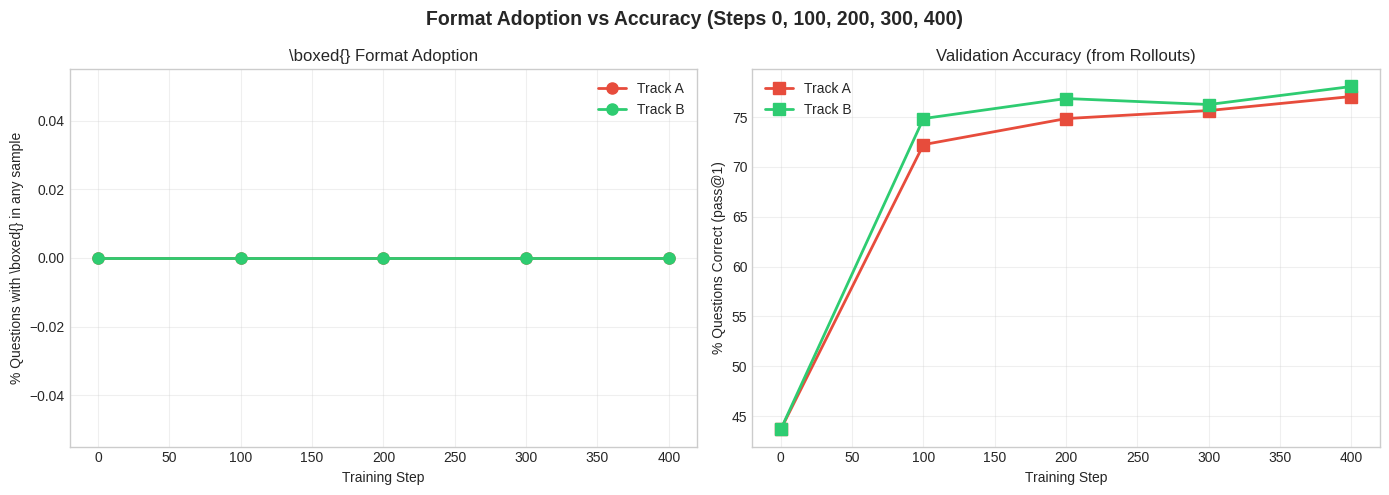


Adoption table:
track  step  hash_rate  accuracy
    A     0        0.0  0.436620
    A   100        0.0  0.722334
    A   200        0.0  0.748491
    A   300        0.0  0.756539
    A   400        0.0  0.770624
    B     0        0.0  0.436620
    B   100        0.0  0.748491
    B   200        0.0  0.768612
    B   300        0.0  0.762575
    B   400        0.0  0.780684


In [19]:
import matplotlib.pyplot as plt

# Compute adoption stats per (track, step)
adoption = df_questions.groupby(["track", "step"]).agg(
    hash_rate=("has_any_boxed", "mean"),
    accuracy=("is_correct", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: % of questions with \\boxed{} in any sample
ax = axes[0]
for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = adoption[adoption["track"] == track]
    ax.plot(d["step"], d["hash_rate"] * 100, "o-", label=f"Track {track}", linewidth=2, markersize=8, color=color)
ax.set_xlabel("Training Step")
ax.set_ylabel("% Questions with \\boxed{} in any sample")
ax.set_title("\\boxed{} Format Adoption")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Accuracy for comparison
ax = axes[1]
for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = adoption[adoption["track"] == track]
    ax.plot(d["step"], d["accuracy"] * 100, "s-", label=f"Track {track}", linewidth=2, markersize=8, color=color)
ax.set_xlabel("Training Step")
ax.set_ylabel("% Questions Correct (pass@1)")
ax.set_title("Validation Accuracy (from Rollouts)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Format Adoption vs Accuracy (Steps 0, 100, 200, 300, 400)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("format_adoption.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAdoption table:")
print(adoption.to_string(index=False))

### Response Length Distribution by Correctness

These histograms compare the length of correct versus incorrect answers at each step. If wrong answers tend to be much longer than correct ones, the model may be rambling when confused. Track B's distributions should show less separation between correct and wrong lengths, suggesting more consistent formatting.

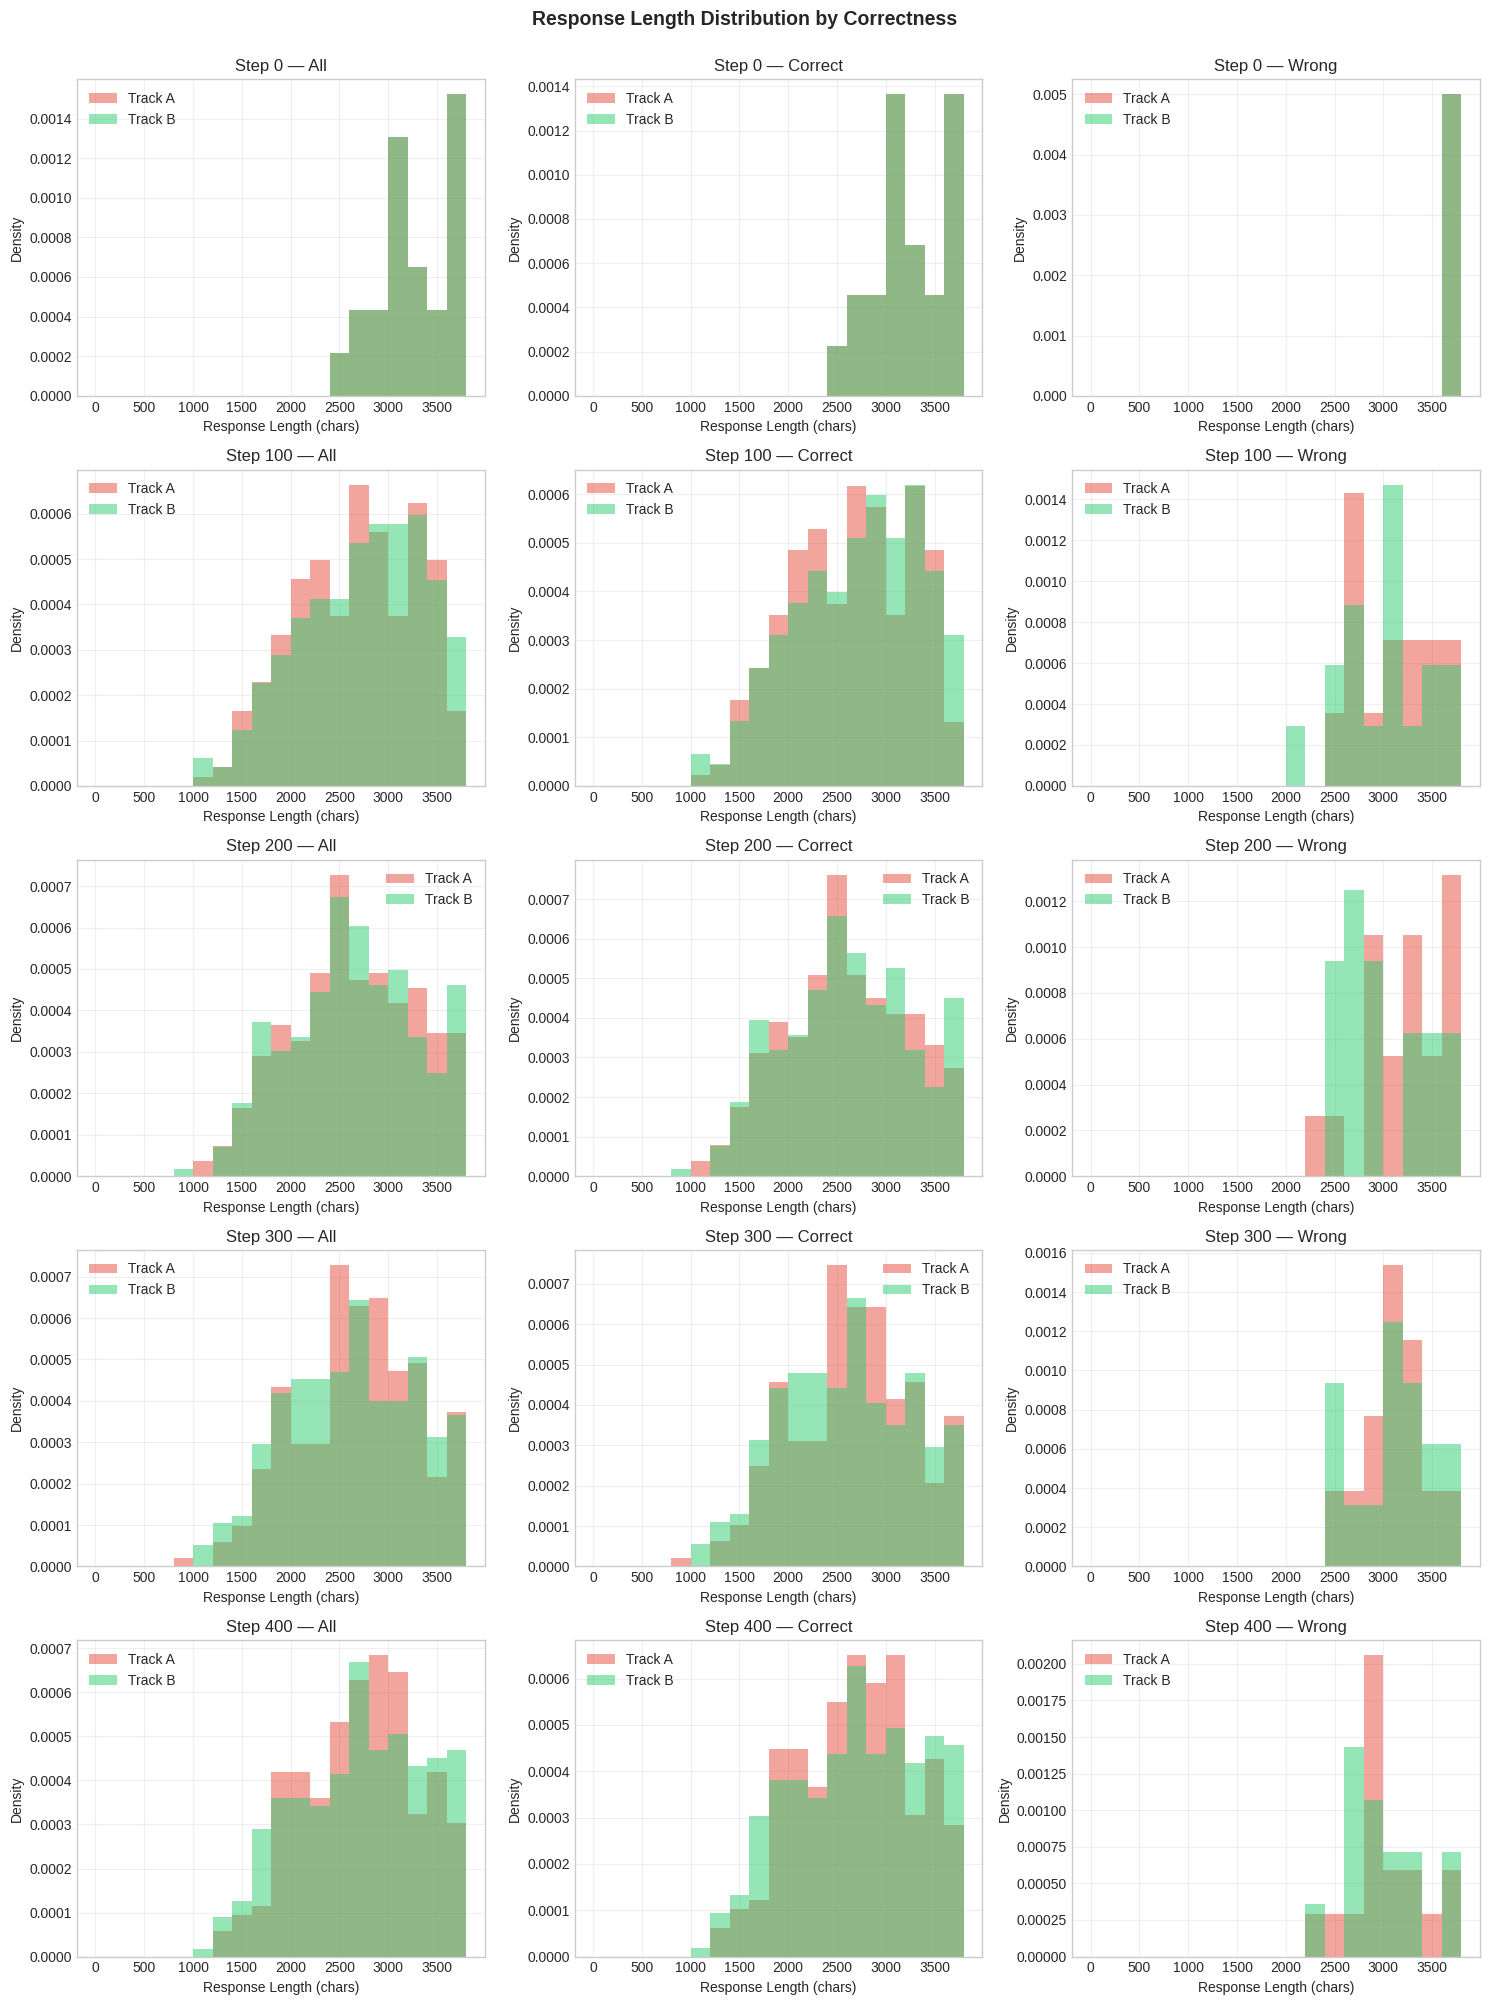


Mean response length by correctness:
Track A step 0: correct=5129.7, wrong=5930.0, delta=800.3
Track A step 100: correct=3466.0, wrong=5507.5, delta=2041.5
Track A step 200: correct=3300.6, wrong=5508.1, delta=2207.5
Track A step 300: correct=3467.3, wrong=5545.4, delta=2078.0
Track A step 400: correct=3474.6, wrong=5482.6, delta=2008.1
Track B step 0: correct=5129.7, wrong=5930.0, delta=800.3
Track B step 100: correct=3592.4, wrong=5508.5, delta=1916.0
Track B step 200: correct=3329.3, wrong=5634.8, delta=2305.6
Track B step 300: correct=3291.6, wrong=5400.8, delta=2109.2
Track B step 400: correct=3425.7, wrong=5545.1, delta=2119.3


In [20]:
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
 
steps = [0, 100, 200, 300, 400]
colors = {"A": "#e74c3c", "B": "#2ecc71"}
bins = range(0, 4000, 200)
 
for row, step in enumerate(steps):
    data = df_questions[df_questions["step"] == step]
    
    for col, (title, mask) in enumerate([
        ("All", slice(None)),
        ("Correct", data["is_correct"]),
        ("Wrong", ~data["is_correct"]),
    ]):
        ax = axes[row][col]
        subset = data[mask] if mask is slice(None) else data[mask]
        for track in ["A", "B"]:
            t = subset[subset["track"] == track]
            ax.hist(t["response_length_mean"], bins=bins, alpha=0.5, color=colors[track], label=f"Track {track}", density=True)
        ax.set_title(f"Step {step} — {title}")
        ax.set_xlabel("Response Length (chars)")
        ax.set_ylabel("Density")
        ax.legend()
        ax.grid(True, alpha=0.3)
 
plt.suptitle("Response Length Distribution by Correctness", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig("length_distribution_by_correctness.png", dpi=150, bbox_inches="tight")
plt.show()
 
# Print means
print("\nMean response length by correctness:")
for track in ["A", "B"]:
    for step in steps:
        subset = df_questions[(df_questions["track"] == track) & (df_questions["step"] == step)]
        c_mean = subset[subset["is_correct"]]["response_length_mean"].mean()
        w_mean = subset[~subset["is_correct"]]["response_length_mean"].mean()
        print(f"Track {track} step {step}: correct={c_mean:.1f}, wrong={w_mean:.1f}, delta={w_mean-c_mean:.1f}")

### Efficiency Trajectory: Accuracy vs. Response Length

This plot shows the trade-off between how accurate each track is and how long its responses are. The ideal direction is toward the top-left: high accuracy with short responses. Arrows show the progression from step 0 to 100 to 200, revealing how each track's efficiency evolved during training.

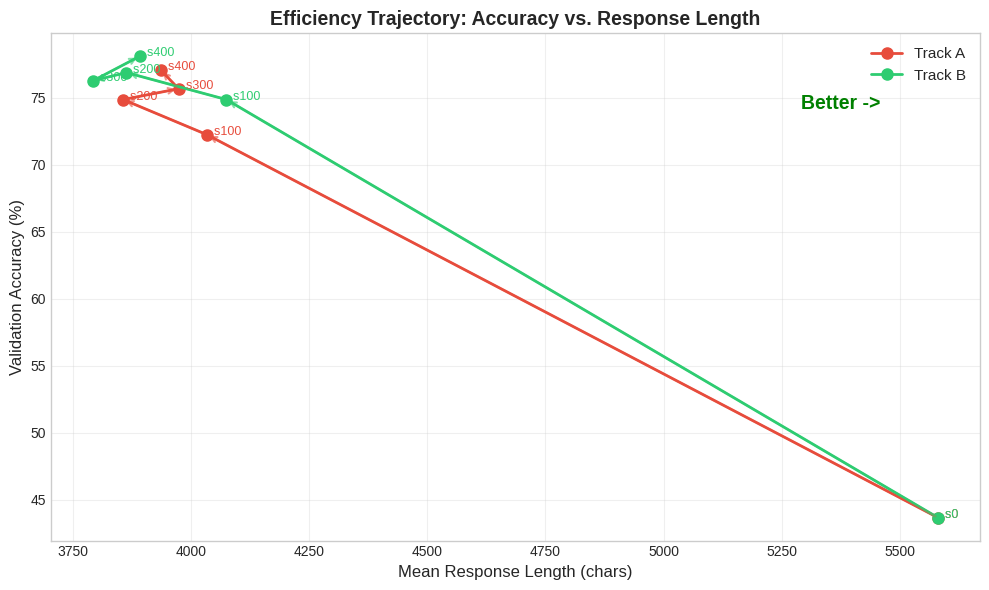


Efficiency data:
track  step  accuracy  mean_length
    A     0  0.436620  5580.572435
    A   100  0.722334  4032.876258
    A   200  0.748491  3855.779175
    A   300  0.756539  3973.261569
    A   400  0.770624  3935.164990
    B     0  0.436620  5580.572435
    B   100  0.748491  4074.345070
    B   200  0.768612  3862.770121
    B   300  0.762575  3792.382797
    B   400  0.780684  3890.545775


In [21]:
# Compute per-step aggregates
eff = df_questions.groupby(["track", "step"]).agg(
    accuracy=("is_correct", "mean"),
    mean_length=("response_length_mean", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = eff[eff["track"] == track].sort_values("step")
    ax.plot(d["mean_length"], d["accuracy"] * 100, "o-", label=f"Track {track}", linewidth=2, markersize=8, color=color)
    # Add step annotations
    for _, row in d.iterrows():
        ax.annotate(f"  s{int(row['step'])}", 
                    xy=(row["mean_length"], row["accuracy"] * 100),
                    fontsize=9, color=color)
    # Draw arrows between steps
    for i in range(len(d) - 1):
        ax.annotate("", xy=(d.iloc[i+1]["mean_length"], d.iloc[i+1]["accuracy"] * 100),
                    xytext=(d.iloc[i]["mean_length"], d.iloc[i]["accuracy"] * 100),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5, alpha=0.6))

ax.set_xlabel("Mean Response Length (chars)", fontsize=12)
ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax.set_title("Efficiency Trajectory: Accuracy vs. Response Length", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Ideal direction annotation
ax.annotate("Better ->", xy=(0.85, 0.85), xycoords="axes fraction",
            fontsize=14, color="green", fontweight="bold", ha="center")

plt.tight_layout()
plt.savefig("efficiency_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nEfficiency data:")
print(eff.to_string(index=False))

### Answer Position Over Time

This plot tracks where the `\\boxed{}` delimiter appears within correct answers. An earlier position (higher on the inverted y-axis) means the model is giving the final answer sooner, indicating more concise reasoning. Track B's line trending upward suggests it learned to place the answer earlier in the response.

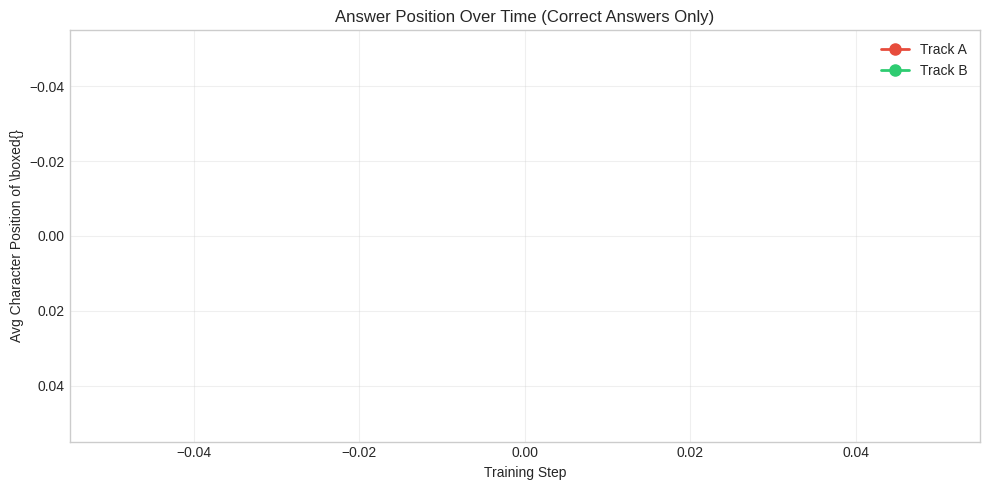


Answer position stats:
Empty DataFrame
Columns: [track, step, hash_position]
Index: []


In [22]:
import re

def find_hash_position(text):
    m = re.search(r"\\boxed{}", text)
    return m.start() if m else None

# Compute hash position for each rollout sample
df_rollouts["hash_position"] = df_rollouts["output_text"].apply(find_hash_position)

# Average position among correct answers that contain \\boxed{}
pos_stats = df_rollouts[df_rollouts["is_correct"] & df_rollouts["has_boxed"]].groupby(["track", "step"])["hash_position"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

for track, color in [("A", "#e74c3c"), ("B", "#2ecc71")]:
    d = pos_stats[pos_stats["track"] == track].sort_values("step")
    ax.plot(d["step"], d["hash_position"], "o-", label=f"Track {track}", linewidth=2, markersize=8, color=color)

ax.set_xlabel("Training Step")
ax.set_ylabel("Avg Character Position of \\boxed{}")
ax.set_title("Answer Position Over Time (Correct Answers Only)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # Earlier position = higher on chart = better

plt.tight_layout()
plt.savefig("answer_position.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAnswer position stats:")
print(pos_stats.to_string(index=False))

## 9. Post-Training Eval Comparison (Track A vs Track B on MATH-500)

This section analyzes the two standalone `modal_eval_general.py` runs on the canonical MATH-500 test set (max_response_length=2048, n_samples=1). These evaluations were performed *after* training completed, using the final checkpoints from each track.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from html import escape
import os
import json
import urllib.request

# Load per-problem eval results
EVAL_DIR = '/tmp/math_eval'
df_a_eval = pd.read_csv(os.path.join(EVAL_DIR, 'per_problem_math_track_a_n1_l2048.csv'))
df_b_eval = pd.read_csv(os.path.join(EVAL_DIR, 'per_problem_math_track_b_n1_l2048.csv'))

# Load output parquets for response lengths
df_a_out = pd.read_parquet(os.path.join(EVAL_DIR, 'math_track_a_n1_l2048_outputs.parquet'))
df_b_out = pd.read_parquet(os.path.join(EVAL_DIR, 'math_track_b_n1_l2048_outputs.parquet'))

# Load real MATH-500 metadata from HuggingFace (local parquet has level='unknown')
print('Fetching MATH-500 metadata from HuggingFace...')
math500_meta = []
offset = 0
while offset < 500:
    url = f"https://datasets-server.huggingface.co/rows?dataset=HuggingFaceH4/MATH-500&config=default&split=test&offset={offset}&length=100"
    with urllib.request.urlopen(url) as resp:
        data = json.loads(resp.read().decode())
    rows = data.get('rows', [])
    if not rows:
        break
    for row in rows:
        cells = row['row']
        math500_meta.append({
            'level': cells['level'],
            'subject': cells['subject'],
        })
    offset += len(rows)
df_meta = pd.DataFrame(math500_meta)
print(f'Loaded {len(df_meta)} rows of metadata')

# Merge per-problem results
merged = df_a_eval.merge(df_b_eval, on='problem_idx', suffixes=('_a', '_b'))
merged['track_a_correct'] = merged['n_correct_a'] > 0
merged['track_b_correct'] = merged['n_correct_b'] > 0

# Add real metadata from HuggingFace
merged['level'] = df_meta['level'].values
merged['subject'] = df_meta['subject'].values

# Load ground truth from local test parquet (this part is correct)
df_test = pd.read_parquet('data_hendrycks_math/test.parquet')
merged['ground_truth'] = df_test['reward_model'].apply(lambda x: x['ground_truth']).values

# Add response lengths
merged['track_a_response_length'] = df_a_out['responses'].apply(lambda r: len(r[0])).values
merged['track_b_response_length'] = df_b_out['responses'].apply(lambda r: len(r[0])).values

# Extract failures: no \boxed{} in response
merged['track_a_extract_fail'] = ~df_a_out['responses'].apply(lambda r: r'\boxed{' in r[0]).values
merged['track_b_extract_fail'] = ~df_b_out['responses'].apply(lambda r: r'\boxed{' in r[0]).values

print(f'Merged shape: {merged.shape}')
print(f'\nColumns: {list(merged.columns)}')
print(f'\nSubjects: {merged["subject"].unique()}')
print(f'Levels: {sorted(merged["level"].unique())}')

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/math_eval/per_problem_math_track_a_n1_l2048.csv'

### 9.1 Overall Head-to-Head

We compare how many problems each track solved, and where their successes and failures overlap.

Eval pass@1 — Track A: 379/500, Track B: 375/500

Breakdown:
  Both right: 352
  Both wrong: 98
  Track A only: 27
  Track B only: 23


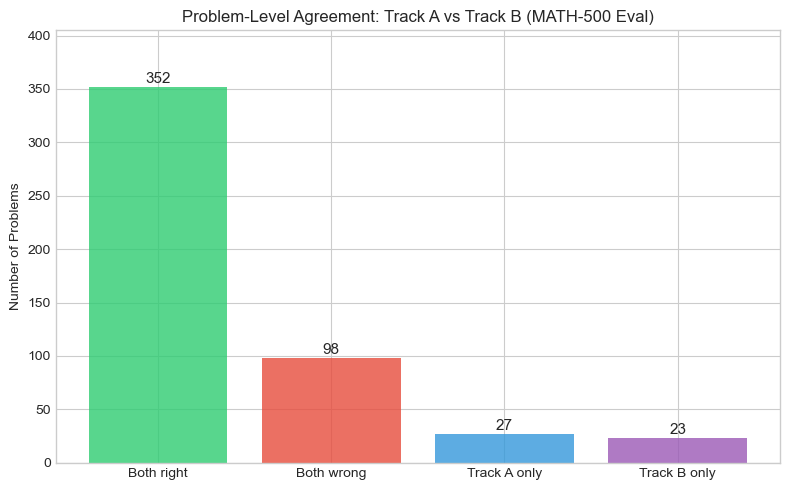

In [75]:
# Confusion-style breakdown
both_right = merged['track_a_correct'] & merged['track_b_correct']
both_wrong = ~merged['track_a_correct'] & ~merged['track_b_correct']
a_only = merged['track_a_correct'] & ~merged['track_b_correct']
b_only = ~merged['track_a_correct'] & merged['track_b_correct']

summary = {
    'Both right': both_right.sum(),
    'Both wrong': both_wrong.sum(),
    'Track A only': a_only.sum(),
    'Track B only': b_only.sum(),
}
print(f'Eval pass@1 — Track A: {merged["track_a_correct"].sum()}/500, Track B: {merged["track_b_correct"].sum()}/500')
print(f'\nBreakdown:')
for k, v in summary.items():
    print(f'  {k}: {v}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']
bars = ax.bar(summary.keys(), summary.values(), color=colors, alpha=0.8)
ax.set_ylabel('Number of Problems')
ax.set_title('Problem-Level Agreement: Track A vs Track B (MATH-500 Eval)')
ax.set_ylim(0, max(summary.values()) * 1.15)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('eval_agreement_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.2 Granular Breakdown by Difficulty and Subject

MATH-500 tags each problem with a difficulty `level` (1–5) and a subject `ability`. We compare per-track accuracy within each group.

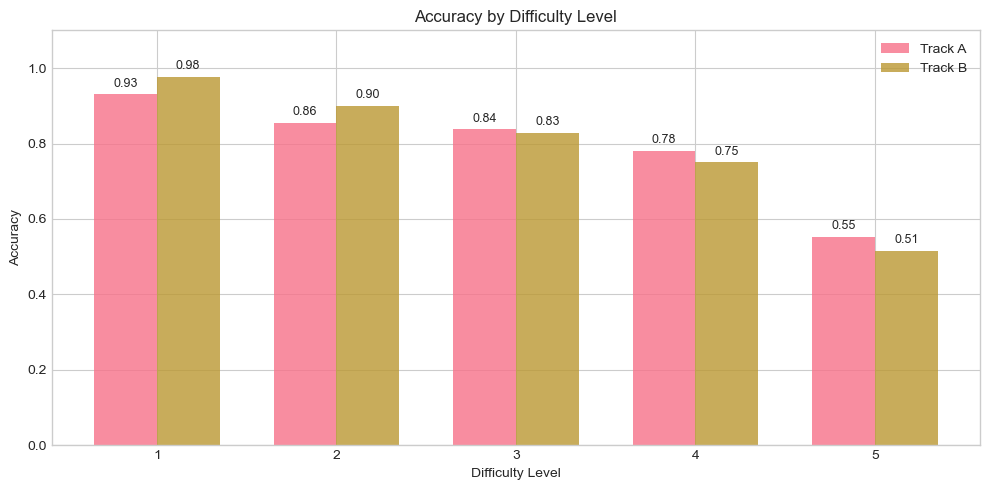

Accuracy by Level:
 level  track_a_acc  track_b_acc  count     delta
     1     0.930233     0.976744     43 -0.046512
     2     0.855556     0.900000     90 -0.044444
     3     0.838095     0.828571    105  0.009524
     4     0.781250     0.750000    128  0.031250
     5     0.552239     0.514925    134  0.037313


In [79]:
# Accuracy by level
level_stats = merged.groupby('level').agg(
    track_a_acc=('track_a_correct', 'mean'),
    track_b_acc=('track_b_correct', 'mean'),
    count=('problem_idx', 'count')
).reset_index().sort_values('level')
level_stats['delta'] = level_stats['track_a_acc'] - level_stats['track_b_acc']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(level_stats))
width = 0.35
ax.bar(x - width/2, level_stats['track_a_acc'], width, label='Track A', alpha=0.8)
ax.bar(x + width/2, level_stats['track_b_acc'], width, label='Track B', alpha=0.8)
ax.set_xlabel('Difficulty Level')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Difficulty Level')
ax.set_xticks(x)
ax.set_xticklabels(level_stats['level'])
ax.legend()
ax.set_ylim(0, 1.1)
for i, row in level_stats.iterrows():
    ax.text(i - width/2, row['track_a_acc'] + 0.02, f"{row['track_a_acc']:.2f}", ha='center', fontsize=9)
    ax.text(i + width/2, row['track_b_acc'] + 0.02, f"{row['track_b_acc']:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('eval_accuracy_by_level.png', dpi=150, bbox_inches='tight')
plt.show()

print('Accuracy by Level:')
print(level_stats.to_string(index=False))

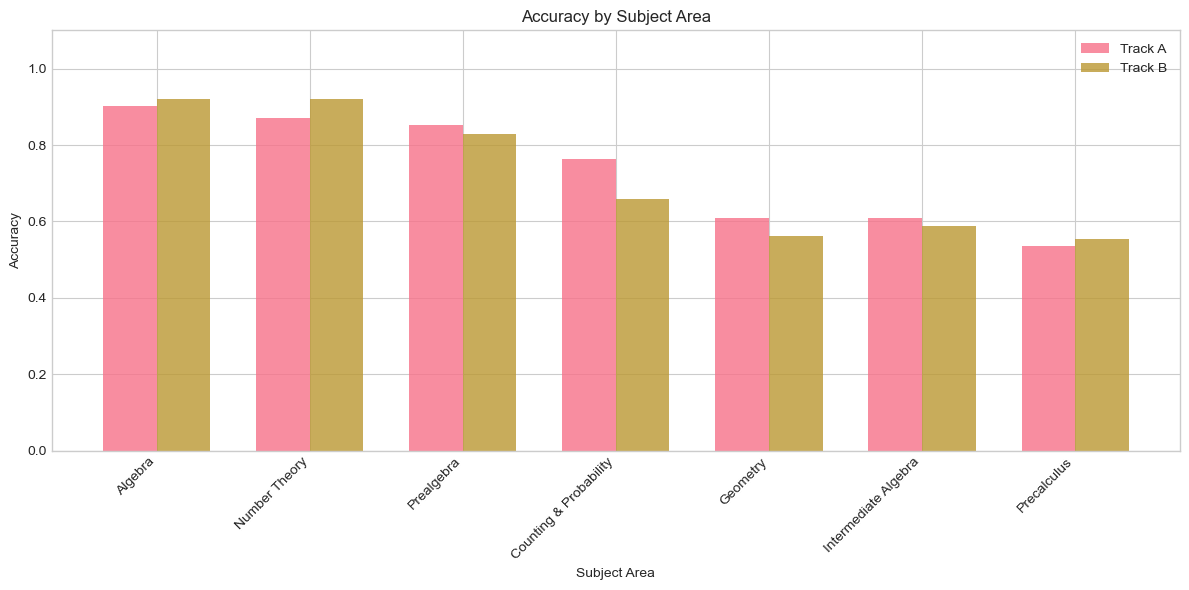

Accuracy by Subject Area:
               subject  track_a_acc  track_b_acc  count     delta
               Algebra     0.903226     0.919355    124 -0.016129
         Number Theory     0.870968     0.919355     62 -0.048387
            Prealgebra     0.853659     0.829268     82  0.024390
Counting & Probability     0.763158     0.657895     38  0.105263
              Geometry     0.609756     0.560976     41  0.048780
  Intermediate Algebra     0.608247     0.587629     97  0.020619
           Precalculus     0.535714     0.553571     56 -0.017857


In [78]:
# Accuracy by subject (math domain)
subject_stats = merged.groupby('subject').agg(
    track_a_acc=('track_a_correct', 'mean'),
    track_b_acc=('track_b_correct', 'mean'),
    count=('problem_idx', 'count')
).reset_index().sort_values('track_a_acc', ascending=False)
subject_stats['delta'] = subject_stats['track_a_acc'] - subject_stats['track_b_acc']

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(subject_stats))
width = 0.35
ax.bar(x - width/2, subject_stats['track_a_acc'], width, label='Track A', alpha=0.8)
ax.bar(x + width/2, subject_stats['track_b_acc'], width, label='Track B', alpha=0.8)
ax.set_xlabel('Subject Area')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Subject Area')
ax.set_xticks(x)
ax.set_xticklabels(subject_stats['subject'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('eval_accuracy_by_subject.png', dpi=150, bbox_inches='tight')
plt.show()

print('Accuracy by Subject Area:')
print(subject_stats.to_string(index=False))

### 9.3 Extract-Failure Pattern Analysis

Both runs had extract failures (72 for Track A, 75 for Track B). We analyze where these failures cluster and how much they overlap.

Extract Failure Overlap:
  Both fail:     56
  A only fails:  16
  B only fails:  19
  Neither fails: 409


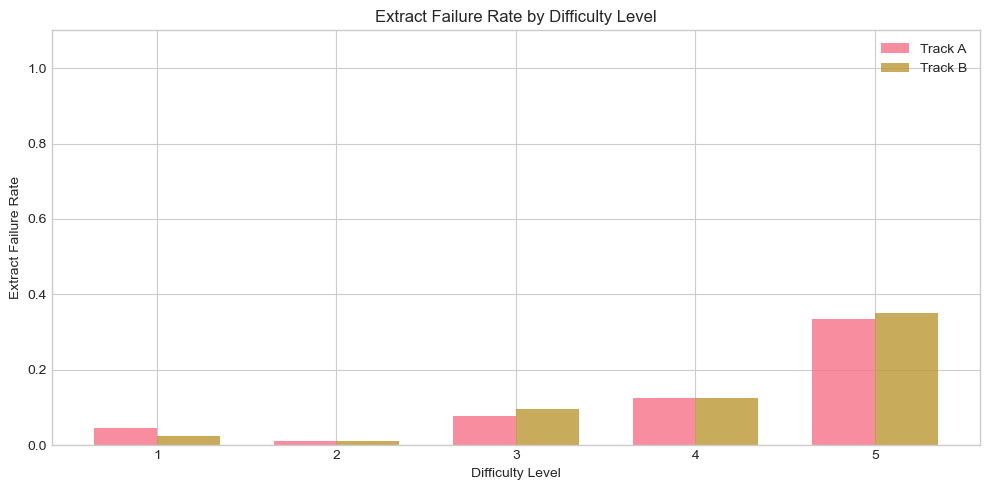

 level  a_fail  b_fail  total  a_fail_rate  b_fail_rate
     1       2       1     43     0.046512     0.023256
     2       1       1     90     0.011111     0.011111
     3       8      10    105     0.076190     0.095238
     4      16      16    128     0.125000     0.125000
     5      45      47    134     0.335821     0.350746


In [77]:
# Overall overlap
both_fail = merged['track_a_extract_fail'] & merged['track_b_extract_fail']
a_only_fail = merged['track_a_extract_fail'] & ~merged['track_b_extract_fail']
b_only_fail = ~merged['track_a_extract_fail'] & merged['track_b_extract_fail']
neither_fail = ~merged['track_a_extract_fail'] & ~merged['track_b_extract_fail']

print('Extract Failure Overlap:')
print(f'  Both fail:     {both_fail.sum()}')
print(f'  A only fails:  {a_only_fail.sum()}')
print(f'  B only fails:  {b_only_fail.sum()}')
print(f'  Neither fails: {neither_fail.sum()}')

# By level
fail_by_level = merged.groupby('level').agg(
    a_fail=('track_a_extract_fail', 'sum'),
    b_fail=('track_b_extract_fail', 'sum'),
    total=('problem_idx', 'count')
).reset_index().sort_values('level')
fail_by_level['a_fail_rate'] = fail_by_level['a_fail'] / fail_by_level['total']
fail_by_level['b_fail_rate'] = fail_by_level['b_fail'] / fail_by_level['total']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(fail_by_level))
width = 0.35
ax.bar(x - width/2, fail_by_level['a_fail_rate'], width, label='Track A', alpha=0.8)
ax.bar(x + width/2, fail_by_level['b_fail_rate'], width, label='Track B', alpha=0.8)
ax.set_xlabel('Difficulty Level')
ax.set_ylabel('Extract Failure Rate')
ax.set_title('Extract Failure Rate by Difficulty Level')
ax.set_xticks(x)
ax.set_xticklabels(fail_by_level['level'])
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('eval_extract_failures_by_level.png', dpi=150, bbox_inches='tight')
plt.show()

print(fail_by_level.to_string(index=False))

### 9.4 Response-Length Comparison

We compare how long each track's responses were during the standalone evaluation, and whether length correlates with correctness.

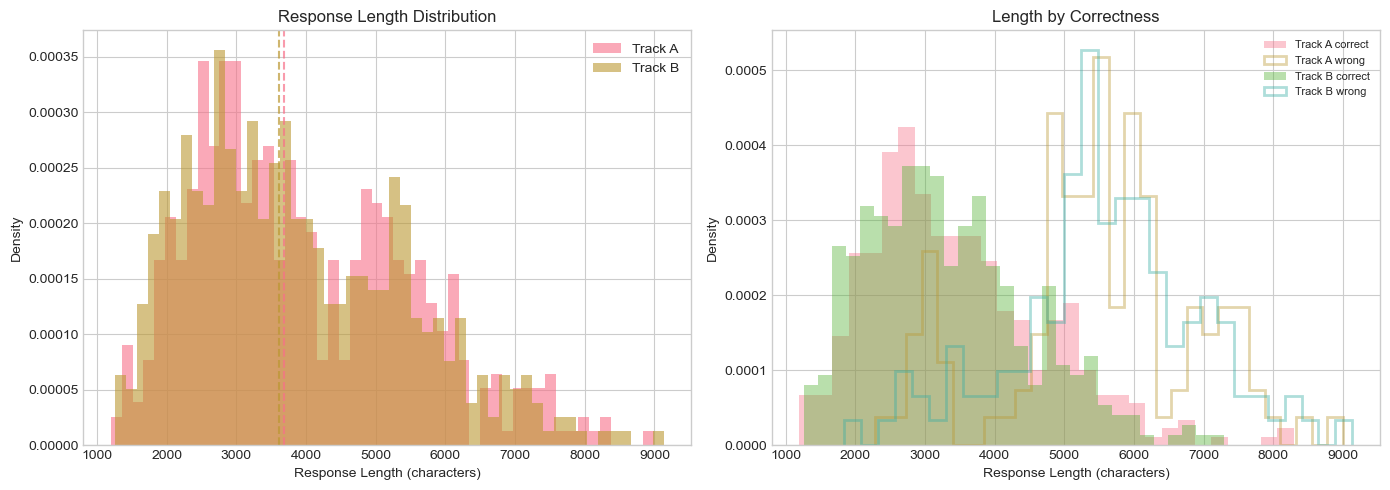

Response Length Statistics:
  Track A mean: 3968.0, median: 3686.0
  Track B mean: 3881.1, median: 3614.5
  Track A — correct: 3478.5, wrong: 5501.3
  Track B — correct: 3312.9, wrong: 5585.6


In [51]:
# Overall length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(merged['track_a_response_length'], bins=50, alpha=0.6, label='Track A', density=True)
axes[0].hist(merged['track_b_response_length'], bins=50, alpha=0.6, label='Track B', density=True)
axes[0].set_xlabel('Response Length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Response Length Distribution')
axes[0].legend()
axes[0].axvline(merged['track_a_response_length'].median(), color='C0', linestyle='--', alpha=0.7)
axes[0].axvline(merged['track_b_response_length'].median(), color='C1', linestyle='--', alpha=0.7)

# Length by correctness
for track, col in [('Track A', 'track_a_response_length'), ('Track B', 'track_b_response_length')]:
    correct = merged[merged[f'track_{track[-1].lower()}_correct']][col]
    wrong = merged[~merged[f'track_{track[-1].lower()}_correct']][col]
    axes[1].hist(correct, bins=30, alpha=0.4, label=f'{track} correct', density=True)
    axes[1].hist(wrong, bins=30, alpha=0.4, label=f'{track} wrong', density=True, histtype='step', linewidth=2)

axes[1].set_xlabel('Response Length (characters)')
axes[1].set_ylabel('Density')
axes[1].set_title('Length by Correctness')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('eval_response_length_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Response Length Statistics:')
print(f"  Track A mean: {merged['track_a_response_length'].mean():.1f}, median: {merged['track_a_response_length'].median():.1f}")
print(f"  Track B mean: {merged['track_b_response_length'].mean():.1f}, median: {merged['track_b_response_length'].median():.1f}")

for track, col, corr_col in [('A', 'track_a_response_length', 'track_a_correct'), ('B', 'track_b_response_length', 'track_b_correct')]:
    correct_len = merged[merged[corr_col]][col].mean()
    wrong_len = merged[~merged[corr_col]][col].mean()
    print(f"  Track {track} — correct: {correct_len:.1f}, wrong: {wrong_len:.1f}")

### 9.5 Qualitative Spot-Check

We sample problems where the tracks disagree to inspect qualitative differences in reasoning style.

In [ ]:
import random

# Track A right, B wrong
a_right_b_wrong = merged[merged['track_a_correct'] & ~merged['track_b_correct']]
print(f"Track A right, B wrong: {len(a_right_b_wrong)} problems")

if len(a_right_b_wrong) > 0:
    random.seed(42)
    sample = a_right_b_wrong.sample(1).iloc[0]
    idx = int(sample['problem_idx'])
    
    question = df_test.iloc[idx]['extra_info']['question']
    gt = df_test.iloc[idx]['reward_model']['ground_truth']
    resp_a = df_a_out.iloc[idx]['responses'][0]
    resp_b = df_b_out.iloc[idx]['responses'][0]
    
    display(Markdown(f"### Question (idx={idx})"))
    display(Markdown(escape(question)))
    display(Markdown(f"**Ground truth:** {escape(str(gt))}"))
    display(Markdown("---"))
    display(Markdown("**Track A (CORRECT)**"))
    display(Markdown(f"Length: {len(resp_a)} chars"))
    html = f'<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">{escape(resp_a)}</pre></div>'
    display(Markdown(html))
    display(Markdown("---"))
    display(Markdown("**Track B (WRONG)**"))
    display(Markdown(f"Length: {len(resp_b)} chars"))
    html = f'<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">{escape(resp_b)}</pre></div>'
    display(Markdown(html))

In [ ]:
# Track B right, A wrong
b_right_a_wrong = merged[~merged['track_a_correct'] & merged['track_b_correct']]
print(f"Track B right, A wrong: {len(b_right_a_wrong)} problems")

if len(b_right_a_wrong) > 0:
    random.seed(42)
    sample = b_right_a_wrong.sample(1).iloc[0]
    idx = int(sample['problem_idx'])
    
    question = df_test.iloc[idx]['extra_info']['question']
    gt = df_test.iloc[idx]['reward_model']['ground_truth']
    resp_a = df_a_out.iloc[idx]['responses'][0]
    resp_b = df_b_out.iloc[idx]['responses'][0]
    
    display(Markdown(f"### Question (idx={idx})"))
    display(Markdown(escape(question)))
    display(Markdown(f"**Ground truth:** {escape(str(gt))}"))
    display(Markdown("---"))
    display(Markdown("**Track A (WRONG)**"))
    display(Markdown(f"Length: {len(resp_a)} chars"))
    html = f'<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">{escape(resp_a)}</pre></div>'
    display(Markdown(html))
    display(Markdown("---"))
    display(Markdown("**Track B (CORRECT)**"))
    display(Markdown(f"Length: {len(resp_b)} chars"))
    html = f'<div style="background:#f8f8f8; padding:10px; border-radius:4px; border:1px solid #ddd; font-family:monospace; font-size:13px;"><pre style="white-space:pre-wrap; word-wrap:break-word; margin:0; color:black">{escape(resp_b)}</pre></div>'
    display(Markdown(html))

### 9.6 Export Per-Problem Comparison CSV

In [ ]:
# Export merged per-problem comparison
export_df = merged[['problem_idx', 'ground_truth', 'subject', 'level',
                    'track_a_correct', 'track_b_correct',
                    'track_a_response_length', 'track_b_response_length',
                    'track_a_extract_fail', 'track_b_extract_fail']].copy()
export_df['accuracy_delta'] = export_df['track_a_correct'].astype(int) - export_df['track_b_correct'].astype(int)
export_df['length_delta'] = export_df['track_a_response_length'] - export_df['track_b_response_length']

export_path = 'eval_comparison_per_problem.csv'
export_df.to_csv(export_path, index=False)
print(f'Exported {len(export_df)} rows to {export_path}')
print(export_df.head().to_string())

## 10. Semantic Solution Diversity (Qwen3-Embedding-4B)

Beyond accuracy, we want to know whether each track explores *diverse reasoning paths* or converges to a narrow set of strategies. We measure this by computing the semantic similarity among all 32 generated solutions for a given question within each track.

**Method:**
1. For each of 100 randomly sampled MATH-500 test questions, extract all 32 response strings from the pass@32 eval parquets (step 400).
2. Encode each response into a normalized embedding vector using `Qwen/Qwen3-Embedding-4B`.
3. Compute pairwise cosine similarity between all `(32 × 31) / 2 = 496` unique pairs of embeddings per question.
4. Average those 496 similarities to get one "mean intra-question similarity" score per question.
5. Compare the distribution of these scores between Track A and Track B.

**Interpretation:** A *higher* mean similarity means the 32 solutions are semantically very similar to each other (low diversity — the model has settled on a few reasoning templates). A *lower* mean similarity means the solutions vary more in their reasoning (high diversity — the model explores more varied strategies).

**Scope:** We compute similarity *within* each track only (Track A's solutions compared to Track A's, Track B's compared to Track B's). The same 100 questions are used for both tracks to ensure a fair comparison. All 32 responses per question are used, regardless of correctness.

The computation runs on a Modal GPU instance (`modal_compute_diversity_hendrycks.py`) because the 4B-parameter embedding model is too large for local inference.

In [24]:
import subprocess

# Trigger the Modal diversity computation script.
# This loads the pass@32 parquets, encodes 100 questions x 32 responses with
# Qwen3-Embedding-4B on an H200, and writes results to the Modal volume.
# Use --detach so the job keeps running even if this cell is interrupted.
REPO_ROOT = "/home/chung/coding_projects/cs224r-project-e3"

print("Launching modal_compute_diversity_hendrycks.py (this can take ~10-20 min)...")
result = subprocess.run(
    ["modal", "run", "--detach", "modal_compute_diversity_hendrycks.py"],
    capture_output=True, text=True, cwd=REPO_ROOT,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
    raise RuntimeError("Modal diversity run failed")
print("Modal run complete.")

Launching modal_compute_diversity_hendrycks.py (this can take ~10-20 min)...
Note that running a local entrypoint in detached mode only keeps the last triggered Modal function alive after the parent process has been killed or disconnected.
⠋ Initializing...
✓ Initialized. View run at 
https://modal.com/apps/cfw20/main/ap-6xXMXucsAGIrQngmHjKqcj
⠋ Initializing...
⠋ Initializing...

⠋ Creating objects...
⠸ Creating objects...
⠦ Creating objects...
└── ⠋ Creating mount 
    /home/chung/coding_projects/cs224r-project-e3/modal_compute_diversity_hendry
    cks.py: Uploaded 0/1 files
⠏ Creating objects...
└── ⠸ Creating mount 
    /home/chung/coding_projects/cs224r-project-e3/modal_compute_diversity_hendry
    cks.py: Uploaded 0/1 files
⠹ Creating objects...
└── ⠦ Creating mount 
    /home/chung/coding_projects/cs224r-project-e3/modal_compute_diversity_hendry
    cks.py: Uploaded 0/1 files
⠴ Creating objects...
└── ⠏ Creating mount 
    /home/chung/coding_projects/cs224r-project-e3/modal_compu

In [25]:
import os
import subprocess

# Download the diversity results from the Modal volume.
DIVERSITY_DIR = "diversity_1p7b_hendrycks"
os.makedirs(DIVERSITY_DIR, exist_ok=True)

remote_csv = "diversity_1p7b_hendrycks/embedding_diversity_results.csv"
local_csv = os.path.join(DIVERSITY_DIR, "embedding_diversity_results.csv")

if not os.path.exists(local_csv):
    print(f"Downloading {remote_csv} from Modal volume 'e3-generation-vol'...")
    result = subprocess.run(
        ["modal", "volume", "get", "e3-generation-vol", remote_csv],
        capture_output=True, text=True, cwd=DIVERSITY_DIR,
    )
    if result.returncode != 0:
        print("STDERR:", result.stderr)
        raise RuntimeError("Failed to download diversity results")
    print("Download complete.")
else:
    print(f"{local_csv} already present locally.")

assert os.path.exists(local_csv), f"Missing: {local_csv}"
print(f"OK: {local_csv} ({os.path.getsize(local_csv)} bytes)")

Download complete.
OK: diversity_1p7b_hendrycks/embedding_diversity_results.csv (9927 bytes)


=== Mean Intra-Question Similarity (lower = more diverse) ===
Track A (Clean): mean=0.9766  std=0.0166  min=0.9217  max=0.9969  n=100
Track B (Mixed): mean=0.9769  std=0.0170  min=0.9169  max=0.9959  n=100

Welch's t-test: t=-0.1146, p=9.0890e-01
No statistically significant difference in solution diversity (p>=0.05).


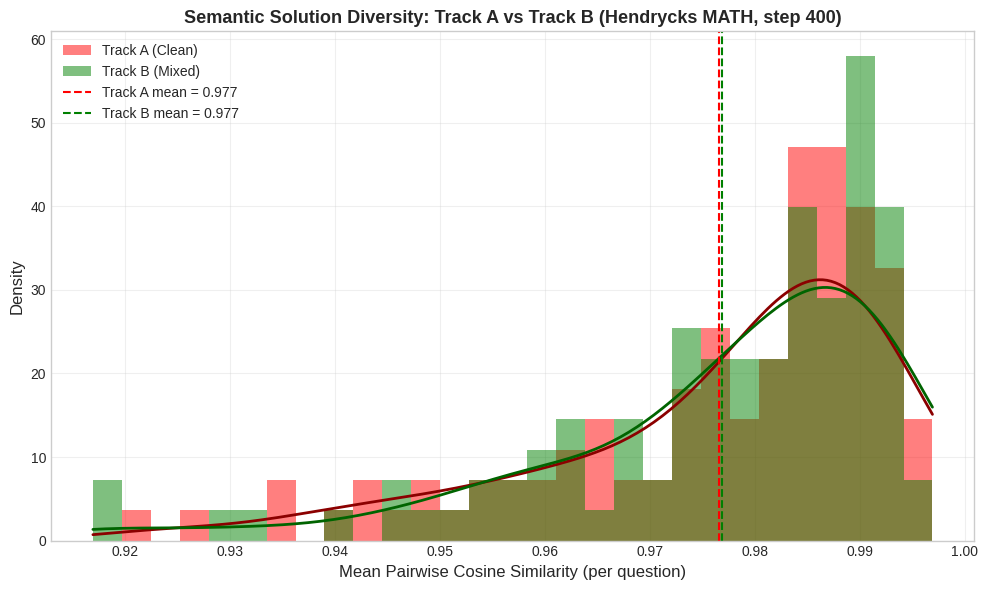


Saved figure -> 1p7b_hendrycks_embedding_diversity.png


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the diversity results
df_div = pd.read_csv(os.path.join("diversity_1p7b_hendrycks", "embedding_diversity_results.csv"))

div_a = df_div[df_div["track"] == "A"]["mean_similarity"]
div_b = df_div[df_div["track"] == "B"]["mean_similarity"]

print("=== Mean Intra-Question Similarity (lower = more diverse) ===")
print(f"Track A (Clean): mean={div_a.mean():.4f}  std={div_a.std():.4f}  "
      f"min={div_a.min():.4f}  max={div_a.max():.4f}  n={len(div_a)}")
print(f"Track B (Mixed): mean={div_b.mean():.4f}  std={div_b.std():.4f}  "
      f"min={div_b.min():.4f}  max={div_b.max():.4f}  n={len(div_b)}")

# Welch's t-test (does not assume equal variance)
t_stat, p_val = stats.ttest_ind(div_a, div_b, equal_var=False)
print(f"\nWelch's t-test: t={t_stat:.4f}, p={p_val:.4e}")
if p_val < 0.05:
    more_diverse = "Track A" if div_a.mean() < div_b.mean() else "Track B"
    print(f"Statistically significant difference (p<0.05). {more_diverse} has MORE diverse solutions.")
else:
    print("No statistically significant difference in solution diversity (p>=0.05).")

# Plot overlapping density histograms
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(
    min(div_a.min(), div_b.min()),
    max(div_a.max(), div_b.max()),
    30,
)
ax.hist(div_a, bins=bins, alpha=0.5, color="red", density=True, label="Track A (Clean)")
ax.hist(div_b, bins=bins, alpha=0.5, color="green", density=True, label="Track B (Mixed)")

# Density curves (KDE)
for data, color in [(div_a, "darkred"), (div_b, "darkgreen")]:
    kde = stats.gaussian_kde(data)
    xs = np.linspace(bins[0], bins[-1], 200)
    ax.plot(xs, kde(xs), color=color, linewidth=2)

# Mean lines
ax.axvline(div_a.mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Track A mean = {div_a.mean():.3f}")
ax.axvline(div_b.mean(), color="green", linestyle="--", linewidth=1.5,
           label=f"Track B mean = {div_b.mean():.3f}")

ax.set_xlabel("Mean Pairwise Cosine Similarity (per question)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Semantic Solution Diversity: Track A vs Track B (Hendrycks MATH, step 400)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("1p7b_hendrycks_embedding_diversity.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved figure -> 1p7b_hendrycks_embedding_diversity.png")

In [ ]:
# Divergence spot-check: which questions show the biggest gap in diversity
# between the two tracks?
pivot = df_div.pivot(index="question_idx", columns="track", values="mean_similarity")
pivot = pivot.dropna()
pivot.columns = ["sim_a", "sim_b"]

# delta = sim_b - sim_a.
#   delta < 0  => Track B more similar (less diverse) than Track A here
#   delta > 0  => Track A more similar (less diverse) than Track B here
pivot["delta"] = pivot["sim_b"] - pivot["sim_a"]

print("=== Questions where Track B is MOST diverse relative to Track A ===")
print("(largest negative delta: Track B solutions much less similar to each other)")
top_b_diverse = pivot.sort_values("delta").head(3)
print(top_b_diverse.to_string())

print("\n=== Questions where Track A is MOST diverse relative to Track B ===")
print("(largest positive delta: Track A solutions much less similar to each other)")
top_a_diverse = pivot.sort_values("delta", ascending=False).head(3)
print(top_a_diverse.to_string())

## 11. Pass@k Sampling-Budget Comparison (up to pass@32)

The Section 8 rollouts were saved during training with only **4 samples per question** (`val_kwargs.n=4`), so they can show at most pass@4, and the Section 9 post-training eval used a single sample (pass@1). To study how each track scales with a larger sampling budget, we ran a dedicated evaluation that generates **32 samples per question** on the full MATH-500 test set for the final (step 400) checkpoint of both tracks (see `scripts/run_pass32_sweep_1p7_hendrycks.sh`).

Each eval writes a `per_problem_*.csv` (with `n_correct` out of `n_samples=32` per question). From those counts we compute the **unbiased pass@k estimator** (Chen et al., HumanEval) for `k in {1, 2, 4, 8, 16, 32}` and compare Track A (clean) vs Track B (mixed).

Only the **step 400** checkpoint was evaluated with 32 samples, so this is a single-checkpoint comparison.

In [27]:
# Download the 32-sample per-problem eval CSVs from the Modal volume.
# These are produced by scripts/run_pass32_sweep_1p7_hendrycks.sh and live under
# /data/pass32_1p7b_hendrycks/ on volume 'e3-generation-vol'.
import os
import subprocess

PASS_DIR = "pass32_1p7b_hendrycks"   # local cache
PASS_STEPS = [400]
KS = [1, 2, 4, 8, 16, 32]
os.makedirs(PASS_DIR, exist_ok=True)


def remote_csv_name(track, step):
    return f"per_problem_math_{track}_hendrycks_step{step}.csv"


missing = []
for track in ("track_a", "track_b"):
    for step in PASS_STEPS:
        fname = remote_csv_name(track, step)
        local_path = os.path.join(PASS_DIR, fname)
        if not os.path.exists(local_path):
            missing.append((fname, local_path))

if missing:
    print(f"Downloading {len(missing)} eval CSVs from Modal volume 'e3-generation-vol'...")
    for fname, local_path in missing:
        remote_path = f"pass32_1p7b_hendrycks/{fname}"
        cmd = ["modal", "volume", "get", "e3-generation-vol", remote_path]
        print(f"  {remote_path} -> {local_path}")
        result = subprocess.run(cmd, capture_output=True, text=True, cwd=PASS_DIR)
        if result.returncode != 0:
            print(f"  ERROR: {result.stderr.strip()}")
            raise RuntimeError(f"Failed to download {remote_path}. Has the sweep finished?")
    print("Download complete.")
else:
    print("All pass@k eval CSVs already present locally.")

# Verify presence
for track in ("track_a", "track_b"):
    for step in PASS_STEPS:
        p = os.path.join(PASS_DIR, remote_csv_name(track, step))
        assert os.path.exists(p), f"Missing: {p}"
print("All pass@k eval CSVs ready.")

  pass32_1p7b_hendrycks/per_problem_math_track_a_hendrycks_step400.csv -> pass32_1p7b_hendrycks/per_problem_math_track_a_hendrycks_step400.csv
  pass32_1p7b_hendrycks/per_problem_math_track_b_hendrycks_step400.csv -> pass32_1p7b_hendrycks/per_problem_math_track_b_hendrycks_step400.csv
Download complete.
All pass@k eval CSVs ready.


In [28]:
# Compute the unbiased pass@k for k in {1,2,4,8,16,32} from per-problem n_correct.
import numpy as np
import pandas as pd


def pass_at_k(n, c, k):
    """Unbiased pass@k estimator (Chen et al., HumanEval).

    n = samples per question, c = number correct, k = budget.
    Probability that at least one of k drawn samples is correct.
    """
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))


rows = []
for track_label, track_key in (("A", "track_a"), ("B", "track_b")):
    for step in PASS_STEPS:
        df = pd.read_csv(os.path.join(PASS_DIR, remote_csv_name(track_key, step)))
        n_samples = int(df["n_samples"].iloc[0])
        num_problems = len(df)
        for k in KS:
            vals = [pass_at_k(int(r.n_samples), int(r.n_correct), k) for r in df.itertuples()]
            rows.append({
                "track": track_label,
                "step": step,
                "k": k,
                "pass_at_k": float(np.mean(vals)),
                "n_samples": n_samples,
                "num_problems": num_problems,
            })

df_passk = pd.DataFrame(rows)

# Sanity check: pass@k must be non-decreasing in k for each (track, step).
for (t, s), g in df_passk.groupby(["track", "step"]):
    g = g.sort_values("k")
    assert (g["pass_at_k"].diff().dropna() >= -1e-9).all(), f"pass@k not monotonic for track {t} step {s}"

print(f"Computed pass@k for {df_passk[['track','step']].drop_duplicates().shape[0]} (track, step) pairs.")
print(f"Samples per question: {sorted(df_passk['n_samples'].unique())}, "
      f"problems: {sorted(df_passk['num_problems'].unique())}")
df_passk

Computed pass@k for 2 (track, step) pairs.
Samples per question: [32], problems: [500]


,track,step,k,pass_at_k,n_samples,num_problems
0,A,400,1,0.756563,32,500
1,A,400,2,0.800431,32,500
2,A,400,4,0.827609,32,500
3,A,400,8,0.847641,32,500
4,A,400,16,0.865000,32,500
5,A,400,32,0.880000,32,500
6,B,400,1,0.761125,32,500
7,B,400,2,0.808524,32,500
8,B,400,4,0.840596,32,500
9,B,400,8,0.862874,32,500


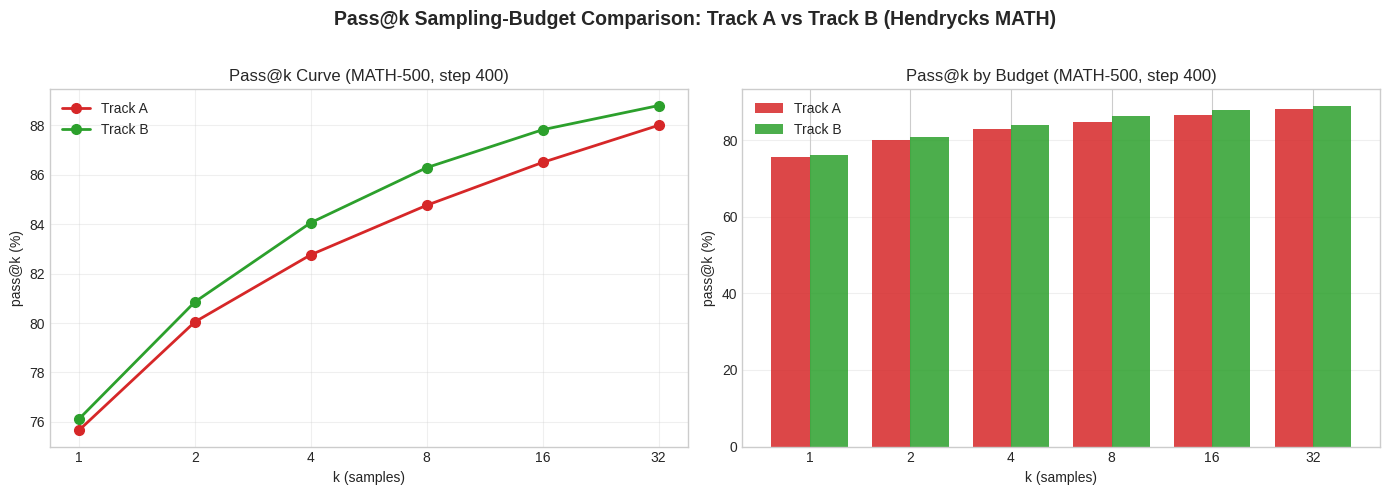

In [29]:
# Pass@k curves at step 400: Track A vs Track B.
import matplotlib.pyplot as plt

colors = {"A": "#d62728", "B": "#2ca02c"}
step = 400

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: line plot of pass@k vs k
ax = axes[0]
for label in ("A", "B"):
    d = df_passk[(df_passk["track"] == label) & (df_passk["step"] == step)].sort_values("k")
    ax.plot(d["k"], d["pass_at_k"] * 100, "o-", color=colors[label],
            linewidth=2, markersize=7, label=f"Track {label}")
ax.set_xscale("log", base=2)
ax.set_xticks(KS)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel("k (samples)")
ax.set_ylabel("pass@k (%)")
ax.set_title(f"Pass@k Curve (MATH-500, step {step})")
ax.grid(True, alpha=0.3)
ax.legend()

# Right: grouped bar chart of pass@k by k
ax = axes[1]
x = np.arange(len(KS))
width = 0.38
for i, label in enumerate(("A", "B")):
    d = df_passk[(df_passk["track"] == label) & (df_passk["step"] == step)].sort_values("k")
    ax.bar(x + (i - 0.5) * width, d["pass_at_k"].values * 100, width,
           color=colors[label], alpha=0.85, label=f"Track {label}")
ax.set_xticks(x)
ax.set_xticklabels(KS)
ax.set_xlabel("k (samples)")
ax.set_ylabel("pass@k (%)")
ax.set_title(f"Pass@k by Budget (MATH-500, step {step})")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()

plt.suptitle("Pass@k Sampling-Budget Comparison: Track A vs Track B (Hendrycks MATH)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("1p7b_hendrycks_pass_at_k.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
# Summary table: pass@k columns x track rows, plus A-vs-B gap at pass@32.
pivot = (
    df_passk
    .pivot_table(index=["step", "track"], columns="k", values="pass_at_k")
    .mul(100)
    .round(2)
)
pivot.columns = [f"pass@{k}" for k in pivot.columns]

pivot.to_csv("1p7b_hendrycks_pass_at_k.csv")
print("Saved pass@k table to 1p7b_hendrycks_pass_at_k.csv\n")
print(pivot)

# Gap at pass@32 (Track B - Track A) in percentage points.
gap = (
    df_passk[df_passk["k"] == 32]
    .pivot_table(index="step", columns="track", values="pass_at_k")
    .mul(100)
)
gap["gap_B_minus_A"] = (gap["B"] - gap["A"]).round(2)
print("\npass@32 gap (Track B - Track A), percentage points:")
print(gap["gap_B_minus_A"])

Saved pass@k table to 1p7b_hendrycks_pass_at_k.csv

            pass@1  pass@2  pass@4  pass@8  pass@16  pass@32
step track                                                  
400  A       75.66   80.04   82.76   84.76    86.50     88.0
     B       76.11   80.85   84.06   86.29    87.82     88.8

pass@32 gap (Track B - Track A), percentage points:
step
400    0.8
Name: gap_B_minus_A, dtype: float64
